# 06 — Familia F2: Clustering

**Qué detecta.** Regímenes como **grupos del espacio de features**: cada sesión se asigna al grupo
(estado) al que más se parece. El grupo de peor retorno y mayor volatilidad del S&P 500 se etiqueta
como *crisis*. No hay cadena de Markov: la memoria temporal, si la hay, entra como una penalización
explícita a los cambios de estado (jump model).

**Supuestos.** GMM: los datos son una mezcla de gaussianas con covarianza completa por estado y cada
día es independiente del anterior. Jump model: los estados son centroides en distancia euclídea sobre
features estandarizadas y cambiar de estado cuesta λ. Ninguno es causal de forma nativa: la
causalidad la impone el walk-forward (reajuste *expanding* y asignación del bloque siguiente) y el
alineado de etiquetas entre reajustes lo resuelve el orden económico canónico.

**Detectores de la familia** (configuración en §2):

| id | detector | idea |
|---|---|---|
| D03 | `clustering_gmm` | mixtura gaussiana estática (K estados, covarianza completa): baseline **no temporal** |
| D09 | `jump_model` | *Statistical Jump Model* (Nystrup et al.): clustering con penalización de salto λ = persistencia aprendida |

D03 y D09 usan **exactamente las mismas features** (núcleo de la pista) y el mismo protocolo, pero
**no son un experimento controlado sobre la persistencia**: además del término temporal (λ) difieren
en el número de estados $K$ (ver §2) y en el modelo de emisión (GMM de covarianza completa frente a
centroides en distancia euclídea). Su diferencia mide el efecto **conjunto** de esos tres cambios;
atribuirla solo a λ exigiría una ablación con el mismo $K$ y la misma emisión, que no se ha hecho.

**Índice**

1. [Teoría de la familia](#s1)
2. [Configuración (desde el registro)](#s2)
3. [Ejecución y carga de resultados](#s3)
4. [Detector a detector](#s4): [D03](#s4-d03) · [D09](#s4-d09) · [qué caracteriza a cada estado](#s4-medias)
5. [Comparación intra-familia: persistencia frente a cobertura](#s5)
6. [Hallazgos de la Capa 1 (v1) y qué cambia en v2](#s6)
   - [6.1 Hipótesis del CHECKPOINT 2 y veredicto (v1 → v2)](#s6-cp2)
7. [Fortalezas, limitaciones y conclusión](#s7)

Todas las cifras del texto se imprimen desde celdas (métricas verificadas por huella de caché,
ranking ADR-003 y métricas congeladas de la Capa 1); ninguna está escrita a mano. Figuras en
`results/detectores/f2_clustering/`.

<a id="s1"></a>
## 1. Teoría de la familia F2

### 1.1 El clustering como detector de régimen

El clustering particiona el espacio de features en grupos de observaciones parecidas; cada grupo es
un "estado de mercado" (Münnix et al. `clust_munnix2012` definen así los estados del S&P 500 sobre
matrices de correlación; Two Sigma `clust_twosigma2021regime` obtiene regímenes con un GMM sobre
factores). Frente a las otras familias:

- **Asignación independiente por observación** (versión estática): el régimen de ayer no condiciona
  el de hoy. Es la diferencia esencial con el HMM, que añade una matriz de transición sobre los mismos
  componentes gaussianos. Por eso D03 es el **baseline no temporal** del banco.
- **No causal de forma nativa**: formar los grupos con toda la muestra mira el futuro. Se causaliza con
  el walk-forward (reajuste cada `step` sesiones con el train del fold y asignación del bloque
  siguiente) y resolviendo la **identidad de las etiquetas**, que no es estable entre reajustes: aquí
  cada fold reordena sus estados por criterio económico (0 = calma … K−1 = crisis, según volatilidad
  y retorno del S&P 500 en el train), de modo que "crisis" significa lo mismo en todos los folds.
- **Selección de K**: silueta (`clust_rousseeuw1987silhouette`), *gap statistic*
  (`clust_tibshirani2001gap`), BIC para mixturas (`clust_schwarz1978bic`) u ONC de López de Prado
  (`clust_lopezdeprado2020`).

### 1.2 D03 — mixtura gaussiana (GMM) con covarianza completa

$$
p(x)=\sum_{k=1}^{K}\pi_k\,\mathcal N(x\mid\mu_k,\Sigma_k),\qquad
\gamma_{tk}=P(s_t=k\mid x_t)=\frac{\pi_k\,\mathcal N(x_t\mid\mu_k,\Sigma_k)}{\sum_{j}\pi_j\,\mathcal N(x_t\mid\mu_j,\Sigma_j)} .
$$

Se estima por EM (varias inicializaciones, regularización diagonal de las covarianzas). La
asignación es **blanda**: la probabilidad de crisis OOS es literalmente $\gamma_{t,\text{crisis}}$ y se
guarda en el panel (`p_crisis`). Con `covariance_type='full'` cada estado tiene su propia matriz de
covarianza, lo que permite separar regímenes que difieren en la **estructura de correlación** (el
cambio de signo de la correlación renta variable/bonos, Gulko `gulko2002`) y no solo en volatilidad;
un k-means euclídeo (`clust_lloyd1982kmeans`, `clust_macqueen1967`) o un GMM diagonal no lo verían.
El número de parámetros libres es

$$
p_{\text{GMM}}=(K-1)+Kd+K\,\frac{d(d+1)}{2},\qquad \text{BIC}=-2\,\ell+p_{\text{GMM}}\ln n ,
$$

que crece cuadráticamente con el número de features $d$. Debilidades conocidas: **parpadeo** (sin
término de persistencia, los días-frontera saltan de etiqueta de una sesión a la siguiente) y
componentes gaussianos que se "gastan" en absorber las colas gordas.

### 1.3 D09 — *Statistical Jump Model* (SJM)

Nystrup, Lindström y Madsen (`hmm_nystrup2020`) proponen un clustering con **penalización de salto**:

$$
\min_{\{\mu_k\},\,\{s_t\}}\;\sum_{t=1}^{T}\tfrac12\,\lVert x_t-\mu_{s_t}\rVert^2\;+\;\lambda\sum_{t=2}^{T}\mathbb 1[s_t\neq s_{t-1}] .
$$

Se resuelve por descenso por coordenadas: dados los centroides, la secuencia óptima de estados sale
de una **programación dinámica** tipo Viterbi ($O(TK^2)$); dados los estados, cada centroide es la
media de sus sesiones. Casos límite: $\lambda=0$ es **k-means**; $\lambda\to\infty$ congela un único
estado. λ actúa como una **histéresis aprendida** (el equivalente estadístico de la banda muerta de
las reglas F1): penaliza cambiar de régimen sin imponer una matriz de transición, y equivale a un HMM
con emisiones gaussianas isótropas y transiciones simétricas en el que $\lambda$ hace el papel de
$-\log$ de la probabilidad de cambio (de ahí el título del artículo: *aprender HMM con estados
persistentes penalizando saltos*; ver también `hmm_nystrup2017`).

**Causalidad.** La DP sobre toda la ventana mira el futuro dentro del bloque; el detector usa la
versión **online** (`predict_online`), en la que la etiqueta de la sesión $i$ usa solo sesiones
anteriores, y el walk-forward antepone contexto (ADR-003) para que la recursión online llegue al
bloque con su estado. Las features se estandarizan con un `StandardScaler` ajustado **solo con el
train** (la distancia euclídea es sensible a la escala: ya en la Capa 1 las features de correlación,
drawdown y momentum tenían una escala muy inferior a la del resto y, sin reescalar, quedarían
infra-ponderadas frente a las de volatilidad). La versión discreta devuelve probabilidades
*one-hot*, así que su `p_crisis` OOS es 0/1.

### 1.4 Frontera con otras familias

Añadir una cadena de Markov a los componentes del GMM lo convierte en un GMM-HMM (familia F3); el SJM
es el **puente** F2↔F3 (persistencia sin transición probabilística). DBSCAN/HDBSCAN
(`clust_ester1996dbscan`, `clust_campello2013hdbscan`) se descartaron como particionadores porque
marcan los días de crisis, raros y dispersos, como ruido; el k-means de Wasserstein
(`clust_horvath2021wasserstein`) queda como línea futura.

### 1.5 Fortalezas y debilidades teóricas

| eje | D03 GMM estático | D09 jump model |
|---|---|---|
| dinámica temporal | ninguna | penalización de salto λ |
| supuesto distribucional | mezcla gaussiana, covarianza completa | ninguno explícito (distancia euclídea) |
| crisis rápidas | reacciona, sin memoria | amortiguadas por λ (filtro paso-bajo) |
| parpadeo | muy alto | bajo; controlado por λ |
| causalidad | re-fit expanding + orden canónico | idem + predicción online |
| probabilidad | sí (posterior) | no (one-hot) |
| coste | bajo | medio (DP + varias inicializaciones por refit) |

Referencias (claves de `docs/references.bib`): `clust_munnix2012`, `clust_twosigma2021regime`,
`gulko2002`, `lopezdeprado2018`, `clust_lopezdeprado2020`, `clust_rousseeuw1987silhouette`,
`clust_tibshirani2001gap`, `clust_schwarz1978bic`, `clust_lloyd1982kmeans`, `clust_macqueen1967`,
`clust_ester1996dbscan`, `clust_campello2013hdbscan`, `clust_horvath2021wasserstein`,
`hmm_nystrup2020`, `hmm_nystrup2017`. Fichas completas: `docs/teoria/F2_clustering.md`,
`docs/teoria/00_estado_del_arte.md` (§4.2, candidatas), `docs/detectores/D03_*.md` y `D09_*.md`.

<a id="s2"></a>

## 2. Configuración (desde el registro)

La configuración sale **íntegra del registro** `regimenes.detectores.registry` (la misma que
usa el benchmark y que entra en la huella de caché): features de entrada por pista, parámetros
declarados en el `DetectorSpec`, parámetros efectivos del constructor (valores por defecto que el
registro no sobrescribe), semilla, frecuencia de reajuste (`step`), tamaño del train inicial y tipo
de ventana. Nada de esta tabla se elige mirando resultados: son hipótesis previas al benchmark.

In [1]:
%matplotlib inline
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from regimenes import informes as inf
from regimenes import rutas, viz
from regimenes.benchmark import DEFAULT_TRAIN_DAYS, configure_evaluation
from regimenes.detectores.registry import SEED
from regimenes.evaluacion import ranking as rk
from regimenes.evaluacion.walk_forward import CONTEXT_YEARS

# --- Configuración común a los notebooks de familia 05–11 ---------------------------------
FAMILIA = 'f2_clustering'                  # figuras en results/detectores/<FAMILIA>/
NOMBRE_FAMILIA = 'F2 — Clustering'
DETECTORES = ['D03', 'D09']
PISTAS = ['A', 'B']
OUTPUT_DIR = rutas.RESULTS_BENCHMARK        # caché del benchmark (aquí solo se lee)
FIG_DIR = inf.carpeta_figuras(FAMILIA)
SPECS = inf.specs_familia(DETECTORES, PISTAS)   # {(pista, id): DetectorSpec} del registro
MIN_RUN = int(rk.DETECTION_DEFAULTS['min_run'])
BETA = float(rk.DETECTION_DEFAULTS['beta'])
rel = inf.ruta_relativa

viz.use_house_style()
inf.opciones_pandas()
warnings.filterwarnings('ignore', category=FutureWarning)


def guardar(fig, nombre):
    """Guarda en results/detectores/<FAMILIA>/<nombre>.png con el estilo de casa (convención 05–11)."""
    return inf.guardar_figura(fig, FIG_DIR, nombre)


# --- Constantes propias de la familia -----------------------------------------------------
V1_MASTER = rutas.DOCS / 'historia' / 'capa1' / 'resultados' / 'metrics_master.csv'
V1_NOMBRE = {'D03': 'clustering_gmm_k3', 'D09': 'jump_model'}  # nombre del detector en la Capa 1 (v1)

print(f'Familia {NOMBRE_FAMILIA}: {", ".join(DETECTORES)} | pistas {", ".join(PISTAS)}')
print('Resultados benchmark :', rel(OUTPUT_DIR))
print('Figuras de la familia:', rel(FIG_DIR))

Familia F2 — Clustering: D03, D09 | pistas A, B
Resultados benchmark : results/benchmark
Figuras de la familia: results/detectores/f2_clustering


In [2]:
CONFIG = inf.tabla_configuracion(SPECS)
display(CONFIG.T)
print(f'Semilla global del registro: SEED = {SEED}; train inicial por pista (sesiones): {DEFAULT_TRAIN_DAYS}; '
      f'contexto de propagación de estado entre bloques (ADR-003): {CONTEXT_YEARS:g} año(s).')

id                                                                D03                                                                                                   D09  \
pista                                                               A                                                  B                                                  A   
detector                                                    GMM (K=3)                                          GMM (K=3)                             Statistical Jump Model   
familia_registro                                           Clustering                                         Clustering                                         Jump model   
clase                                    clustering_gmm.ClusteringGMM                       clustering_gmm.ClusteringGMM                               jump_model.JumpModel   
n_features                                                          9                                                 14                                                  9   
features            SP500_ret_z, SP500_vol_z, SP500_momentum, SP50...  SP500_ret_z, SP500_vol_z, SP500_momentum, SP50...  SP500_ret_z, SP500_vol_z, SP500_momentum, SP50...   
params_declarados                                          n_states=3                                         n_states=3                      n_states=2, jump_penalty=50.0   
params_por_defecto                                                  —                                                  —                                                  —   
params_efectivos                                           n_states=3                                         n_states=3                      n_states=2, jump_penalty=50.0   
semilla                                                            42                                                 42                                                 42   
step                                                               21                                                 21                                                 21   
train_inicial                                     2016 ses. (~8 años)                                 756 ses. (~3 años)                                2016 ses. (~8 años)   
ventana                                                     expanding                                          expanding                                          expanding   
lento                                                           False                                              False                                              False   
variante_v2                                                         —                                                  —                                                  —   

id                                                                     
pista                                                               B  
detector                                       Statistical Jump Model  
familia_registro                                           Jump model  
clase                                            jump_model.JumpModel  
n_features                                                         14  
features            SP500_ret_z, SP500_vol_z, SP500_momentum, SP50...  
params_declarados                       n_states=2, jump_penalty=50.0  
params_por_defecto                                                  —  
params_efectivos                        n_states=2, jump_penalty=50.0  
semilla                                                            42  
step                                                               21  
train_inicial                                      756 ses. (~3 años)  
ventana                                                     expanding  
lento                                                           False  
variante_v2                                                         —

Semilla global del registro: SEED = 42; train inicial por pista (sesiones): {'A': 2016, 'B': 756}; contexto de propagación de estado entre bloques (ADR-003): 1 año(s).


In [3]:
# Número de parámetros libres del GMM (D03) con las features de cada pista.
for t in PISTAS:
    K, dim = SPECS[(t, 'D03')].params['n_states'], len(SPECS[(t, 'D03')].features)
    print(f'D03 pista {t}: K={K}, d={dim} -> {(K - 1) + K * dim + K * dim * (dim + 1) // 2} parámetros; '
          f'D09: K={SPECS[(t, "D09")].params["n_states"]}, λ={SPECS[(t, "D09")].params["jump_penalty"]:g}')

D03 pista A: K=3, d=9 -> 164 parámetros; D09: K=2, λ=50
D03 pista B: K=3, d=14 -> 359 parámetros; D09: K=2, λ=50


<a id="s3"></a>
## 3. Ejecución y carga de resultados

`EJECUTAR = False` (por defecto) **no ajusta nada**: `inf.cargar_resultados_familia` lee la caché
del benchmark con `run_benchmark(cache_only=True)`, que solo acepta una combinación pista/detector si
su huella (código del paquete + datos procesados + especificación + entorno) coincide con la
registrada y el panel OOS existe. Si alguna combinación no está vigente, la celda se detiene con el
comando exacto a lanzar desde la raíz del repositorio (`python -m regimenes.benchmark --track A B
--detector …`). `EJECUTAR = True` pasa el gate previo y reajusta los detectores de esta familia en las
dos pistas con `run_job` (mismo camino que la CLI por detector: escribe `metrics/`, `panels/` y
`status/` de esas combinaciones y no toca `manifest.json` ni `run_status.csv`).

El puesto en el **ranking de detección ADR-003** se lee del `ranking*.csv` que genera
`12_comparativa.ipynb`, comprobando que sus columnas `det_*` coinciden con las métricas verificadas
(si el benchmark se re-ejecutó y 12 no, la celda pide regenerarlo). La segunda celda carga los datos
de apoyo (paneles procesados de cada pista, rejilla común, precio del S&P 500 y ventanas del juez),
que no dependen de `results/`.

In [4]:
EJECUTAR = False   # True = reajusta los detectores de la familia con el protocolo del benchmark (ver 'lento' en §2)
FORZAR = False     # True = ignora la caché vigente al reajustar (solo con EJECUTAR = True)
COMANDO = inf.comando_benchmark(PISTAS, DETECTORES)

if EJECUTAR:
    estados_run = inf.ejecutar_familia(DETECTORES, PISTAS, output_dir=OUTPUT_DIR, forzar=FORZAR)
    display(estados_run[['pista', 'id', 'estado', 'segundos', 'detalle']])
    print('Consolida después manifest.json/run_status.csv con:\n'
          '    python -m regimenes.benchmark --consolidate --track A B')

# Solo lectura de la caché verificada por huella + paneles OOS + ranking ADR-003.
# Si alguna combinación no está vigente, falla con el comando exacto (COMANDO).
RES = inf.cargar_resultados_familia(DETECTORES, PISTAS, output_dir=OUTPUT_DIR)
display(RES.estado_cache[['pista', 'id', 'estado', 'detalle']])
METRICAS = RES.metricas        # métricas verificadas, índice (pista, id)
PANELES = RES.paneles          # {(pista, id): panel OOS con state, p_crisis, fold}
RANKING = RES.ranking          # ranking de detección ADR-003 completo (todas las familias)
RANK = RES.rank                # el mismo ranking indexado por (pista, id)
N_PISTA = RES.n_por_pista      # detectores por pista en el ranking
print(f'Métricas verificadas: {len(METRICAS)} combinaciones pista/detector.')
print(f'Ranking: {rel(RES.ruta_ranking)} (coherente con la caché) · detectores por pista: {N_PISTA}')
print('Parámetros del criterio ADR-003:', rk.DETECTION_DEFAULTS)

,pista,id,estado,detalle
0,A,D03,cache,caché verificada: results\benchmark\metrics\A_...
1,A,D09,cache,caché verificada: results\benchmark\metrics\A_...
2,B,D03,cache,caché verificada: results\benchmark\metrics\B_...
3,B,D09,cache,caché verificada: results\benchmark\metrics\B_...


Métricas verificadas: 4 combinaciones pista/detector.
Ranking: results/benchmark/ranking_v2.csv (coherente con la caché) · detectores por pista: {'A': 12, 'B': 12}
Parámetros del criterio ADR-003: {'min_run': 3, 'beta': 1.0, 'lift_min': 1.0, 'min_mean_duration': 5.0, 'min_crisis_run': 3.0, 'score_decimals': 3}


In [5]:
CTX = inf.cargar_contexto_pistas(PISTAS)   # data/processed + S&P 500 crudo (no depende de results/)
DATOS, INDICE, SP500 = CTX.datos, CTX.indice, CTX.sp500
CRISIS, TRAMPAS = CTX.crisis, CTX.trampas  # ventanas [pico, suelo] del juez por pista y trampas

for t in PISTAS:
    indices = [PANELES[(t, d)].index for d in DETECTORES]
    if not all(ix.equals(indices[0]) for ix in indices):
        raise RuntimeError(f'Pista {t}: los paneles OOS de la familia no comparten índice (gate de 12).')
    oos = indices[0]
    evaluables = [c for c, (a, b) in CRISIS[t].items() if pd.Timestamp(b) >= oos[0]]
    print(f'Pista {t}: OOS {oos[0].date()} -> {oos[-1].date()} ({len(oos)} sesiones); '
          f'{len(evaluables)} de {len(CRISIS[t])} crisis del catálogo con suelo dentro del OOS.')
print('Ventanas trampa (no-crisis):', ', '.join(f'{k} {a}->{b}' for k, (a, b) in TRAMPAS.items()))

Pista A: OOS 1970-05-12 -> 2026-05-29 (14133 sesiones); 17 de 18 crisis del catálogo con suelo dentro del OOS.
Pista B: OOS 2010-04-12 -> 2026-05-29 (4059 sesiones); 9 de 10 crisis del catálogo con suelo dentro del OOS.
Ventanas trampa (no-crisis): taper_2013 2013-05-01->2013-09-13, debtceiling_2013 2013-09-26->2013-10-16


### Utilidades del notebook

Funciones de dibujo y resumen compartidas por todas las secciones. Convenciones:

- **Estados OOS**: columna `state` del panel `results/benchmark/panels/<P>_<D>.parquet` (etiqueta dura
  canónica, 0 = calma … n−1 = crisis) y `p_crisis` (probabilidad de crisis OOS). Todo lo que sale
  de ahí es **causal** (walk-forward).
- **Diagnóstico ilustrativo**: cuando el panel no guarda la señal interna del detector (umbrales,
  score, distancia, centroides), se recomputa con **un único ajuste sobre toda la pista**. Es barato
  pero **no causal** y se rotula siempre como ILUSTRATIVO: sirve para ver el mecanismo, no para
  medir rendimiento.
- Franjas azules = crisis del catálogo de la pista `[pico, suelo]`; franjas grises = ventanas trampa.

In [6]:
# Utilidades comunes 05–11 (implementación en regimenes.informes; aquí solo se fijan los datos).
def estado_crisis(t, d):
    """Estado canónico de crisis del detector (n_states - 1)."""
    return RES.estado_crisis(t, d)


def es_crisis(t, d):
    """Serie booleana OOS: sesión en el estado de crisis."""
    return RES.es_crisis(t, d)


def tabla_cobertura(t, d):
    """Cobertura OOS por crisis (IC bootstrap por bloques), detección por evento y lead/lag."""
    return inf.tabla_cobertura(METRICAS.loc[(t, d)], CRISIS[t])


def tabla_trampas(t, d):
    """Activación en las ventanas trampa (fracción de sesiones marcadas; menor es mejor)."""
    return inf.tabla_trampas(METRICAS.loc[(t, d)], TRAMPAS)


def figura_estados(t, d, diagnostico=None, titulo_diag=None, **kw):
    """Arriba estados OOS sobre el S&P 500 con franjas de crisis/trampas; abajo el diagnóstico
    propio (``diagnostico(ax)``) o, por defecto, P(crisis) OOS del panel."""
    fig, axes = inf.figura_estados_oos(
        SP500, PANELES[(t, d)], RES.n_estados(t, d), crisis=CRISIS[t], trampas=TRAMPAS,
        titulo=f'{d} {SPECS[(t, d)].label} — pista {t}: estados OOS (causal) sobre el S&P 500',
        diagnostico=diagnostico, titulo_diagnostico=titulo_diag, **kw)
    guardar(fig, f'{d}_{t}_estados_oos')
    plt.show()
    return axes


def figura_cobertura(t, d, **kw):
    """Cobertura por crisis (rojo = detectada) y activación en trampas (gris) de una pista."""
    tab = tabla_cobertura(t, d)
    fig, _ = inf.figura_cobertura(
        tab, tabla_trampas(t, d), min_run=MIN_RUN,
        titulo=f'{d} — pista {t}: cobertura OOS por crisis (rojo = detectada, ≥{MIN_RUN} sesiones '
               'seguidas; barras = IC bootstrap; gris = trampas)', **kw)
    guardar(fig, f'{d}_{t}_cobertura_crisis')
    plt.show()
    return tab


def resumen_ranking(ids):
    """Métricas y puesto en el ranking de detección ADR-003 (columna 'de' = detectores en la pista)."""
    return RES.resumen_ranking(ids)


def figura_detector(d, diagnostico, titulo_diag):
    """Por pista, figura_estados con el diagnóstico propio ``diagnostico(ax, t, d)`` debajo."""
    for t in PISTAS:
        figura_estados(t, d, lambda ax, t=t: diagnostico(ax, t, d), titulo_diag)


def lectura_detector(d):
    """Lectura automática (todas las cifras salen de las métricas verificadas y del ranking)."""
    partes = [f'**{d} — {SPECS[(PISTAS[0], d)].label}.**']
    for t in PISTAS:
        r = RANK.loc[(t, d)]
        tab = tabla_cobertura(t, d)
        fila = METRICAS.loc[(t, d)]
        no_det = [c for c in tab.index if tab.loc[c, 'detectada'] != 1]
        trampas = ', '.join(f'`{c[3:]}` {100 * fila[c]:.0f} %' for c in fila.index
                            if c.startswith('fa_') and pd.notna(fila[c])) or 'fuera del OOS'
        partes.append(
            f'*Pista {t}* — puesto **{int(r.puesto_deteccion)} de {int(N_PISTA[t])}** (nivel `{r.nivel_etiqueta}`), '
            f'score = {r.score_deteccion:.3f}; detecta {int(r.det_n_detectados)} de {int(r.det_n_eventos)} crisis '
            f'OOS (recall por evento {r.det_event_recall:.2f}) con precisión diaria {r.det_precision:.2f} '
            f'({r.det_lift_precision:.2f}× la tasa base {r.det_base_rate:.2f}). Marca crisis el '
            f'{100 * r.det_marked_rate:.1f} % de las sesiones, con episodios de crisis de '
            f'{r.det_mean_crisis_run:.1f} sesiones de media y duración media de régimen '
            f'{r.mean_regime_duration:.1f}; activación en trampas: {trampas}. Mejor cubierta: '
            f'`{tab.cobertura.idxmax()}` ({100 * tab.cobertura.max():.0f} %); peor: '
            f'`{tab.cobertura.idxmin()}` ({100 * tab.cobertura.min():.0f} %). '
            + (f'No detectadas: {", ".join(f"`{c}`" for c in no_det)}.' if no_det
               else 'Detecta todas las crisis evaluables.'))
    display(Markdown('\n\n'.join(partes)))


ILUSTRATIVO = {}


def ajuste_ilustrativo(t, d):
    """UN ajuste sobre toda la pista (NO causal). Solo para ver el mecanismo del detector."""
    if (t, d) not in ILUSTRATIVO:
        X = CTX.matriz(t, SPECS[(t, d)].features)
        det = SPECS[(t, d)].factory()
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            det.fit(X)
            det.label_states_economically(X, market_returns=CTX.retornos(t, X.index))
        ILUSTRATIVO[(t, d)] = (det, X)
    return ILUSTRATIVO[(t, d)]

<a id="s4"></a>
## 4. Detector a detector

Para cada detector y pista: (a) estados OOS sobre el S&P 500 con franjas de crisis y trampas, y su
diagnóstico propio debajo; (b) cobertura por crisis con intervalo bootstrap por bloques y marca de
evento detectado (≥ `min_run` sesiones seguidas dentro de `[pico, suelo]`, ADR-003); (c) métricas y
puesto en el ranking de detección; (d) lectura automática.

<a id="s4-d03"></a>
### 4.1 D03 — GMM estático

Diagnóstico: la **probabilidad de crisis OOS** $\gamma_{t,\text{crisis}}$ tal como la guardó el
walk-forward (causal, no es un recálculo). Debajo, los **días-frontera**: sesiones OOS con
$0.2 < p_{\text{crisis}} < 0.8$, donde el posterior se reparte entre componentes; sin memoria temporal
son el caldo de cultivo del parpadeo.

figura -> results/detectores/f2_clustering/D03_A_estados_oos.png


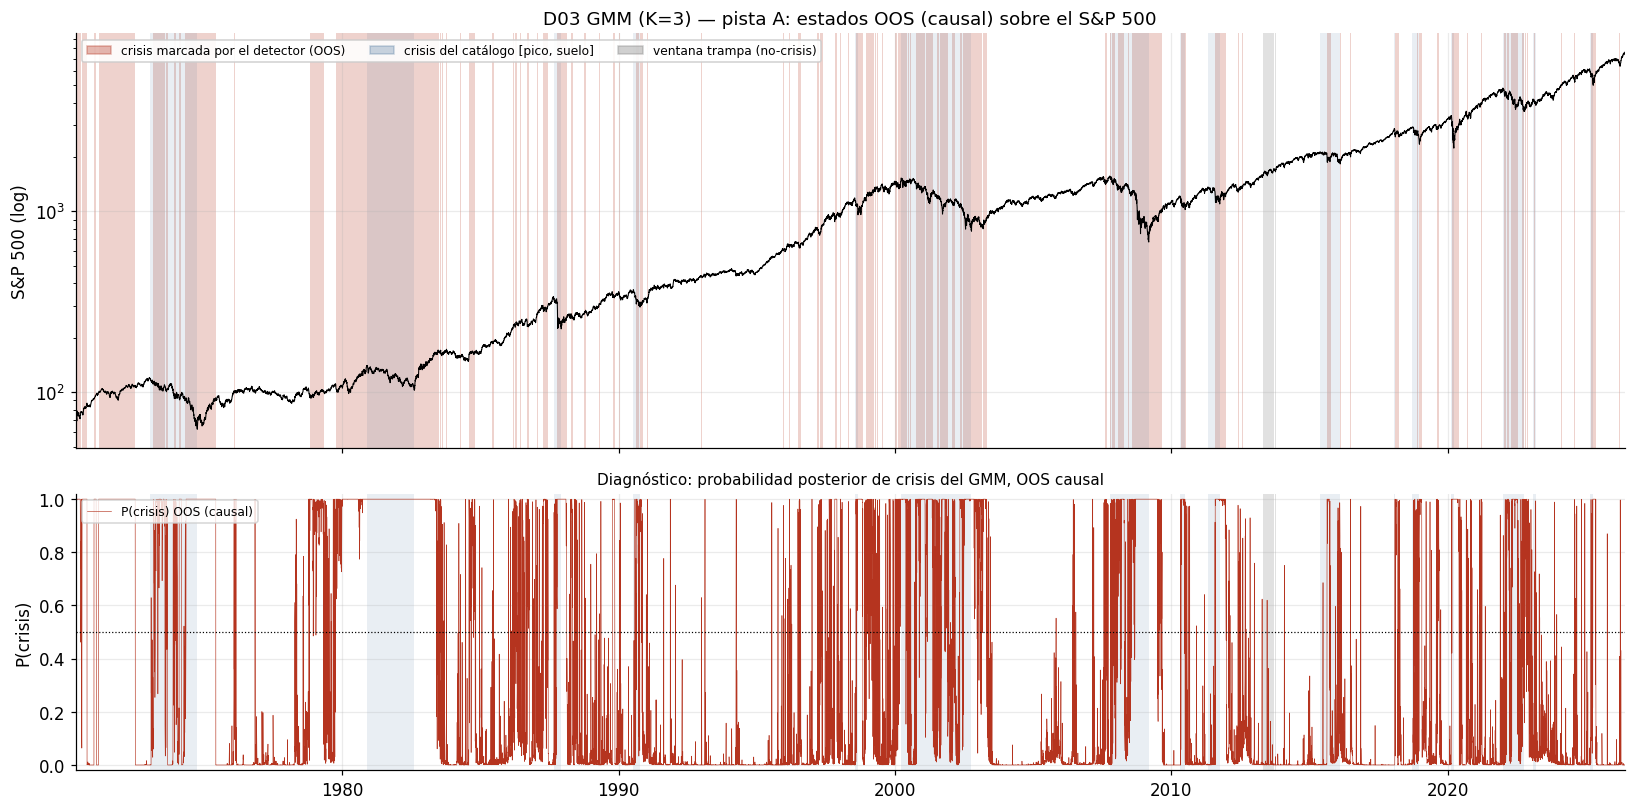

figura -> results/detectores/f2_clustering/D03_B_estados_oos.png


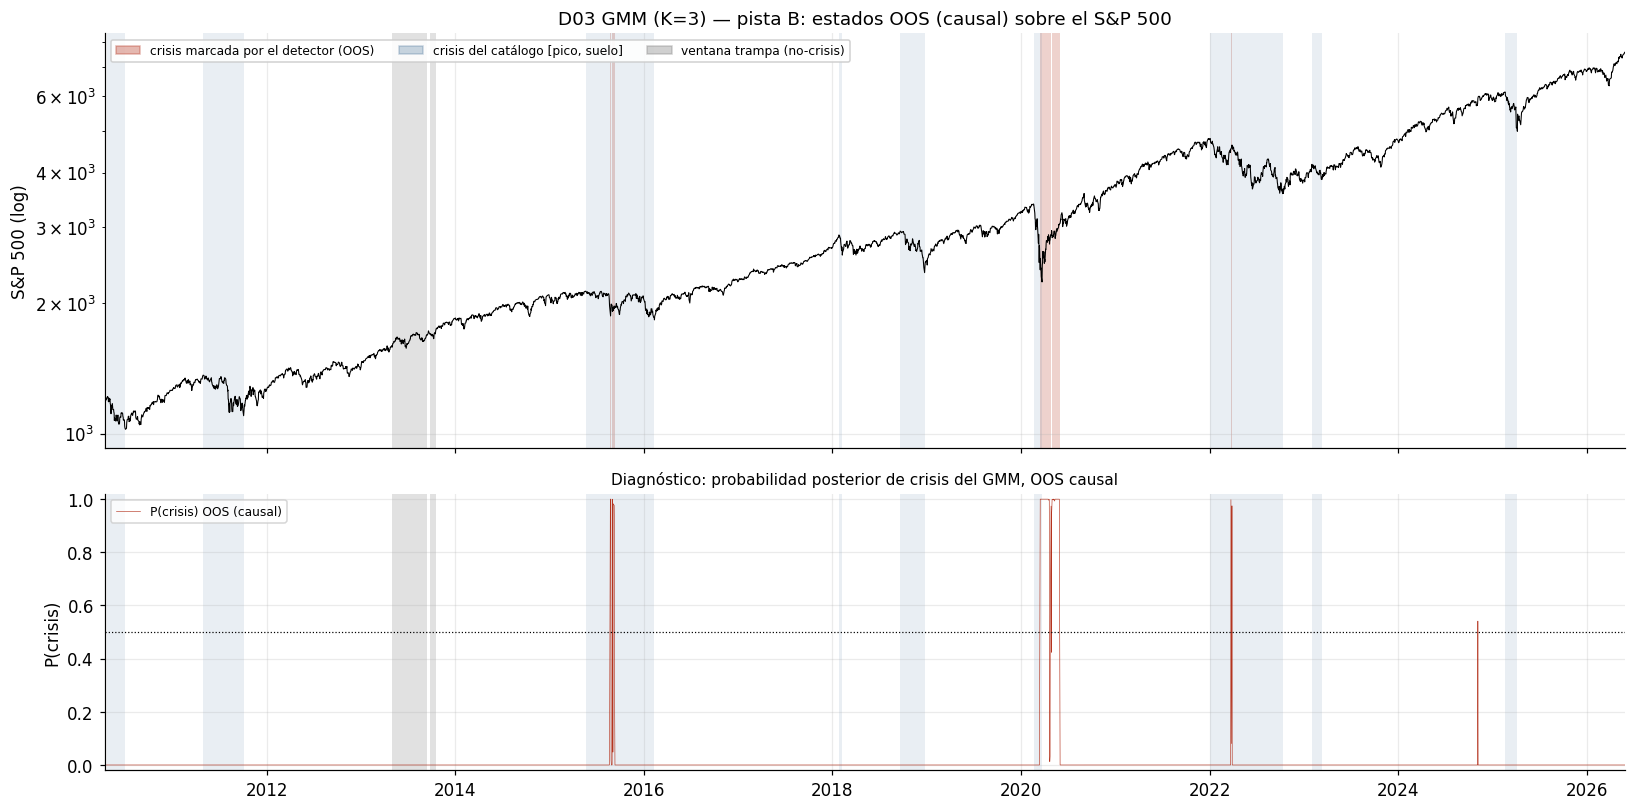

Pista A: días-frontera (0.2 < P(crisis) < 0.8) = 7.5 % de las sesiones OOS; switching_rate = 0.0962
Pista B: días-frontera (0.2 < P(crisis) < 0.8) = 0.1 % de las sesiones OOS; switching_rate = 0.0436


In [7]:
def diag_d03(ax, t, d):
    p = PANELES[(t, d)]['p_crisis']
    ax.plot(p.index, p.values, color=viz.C_CRISIS, lw=0.4, label='P(crisis) OOS (causal)')
    ax.axhline(0.5, color='black', ls=':', lw=0.8)
    ax.set_ylim(-0.02, 1.02)
    ax.set_ylabel('P(crisis)')
    ax.legend(loc='upper left', fontsize=8)


figura_detector('D03', diag_d03, 'Diagnóstico: probabilidad posterior de crisis del GMM, OOS causal')
for t in PISTAS:
    p = PANELES[(t, 'D03')]['p_crisis']
    frontera = p.between(0.2, 0.8, inclusive='neither').mean()
    print(f'Pista {t}: días-frontera (0.2 < P(crisis) < 0.8) = {100 * frontera:.1f} % de las sesiones OOS; '
          f'switching_rate = {METRICAS.loc[(t, "D03"), "switching_rate"]:.4f}')

figura -> results/detectores/f2_clustering/D03_A_cobertura_crisis.png


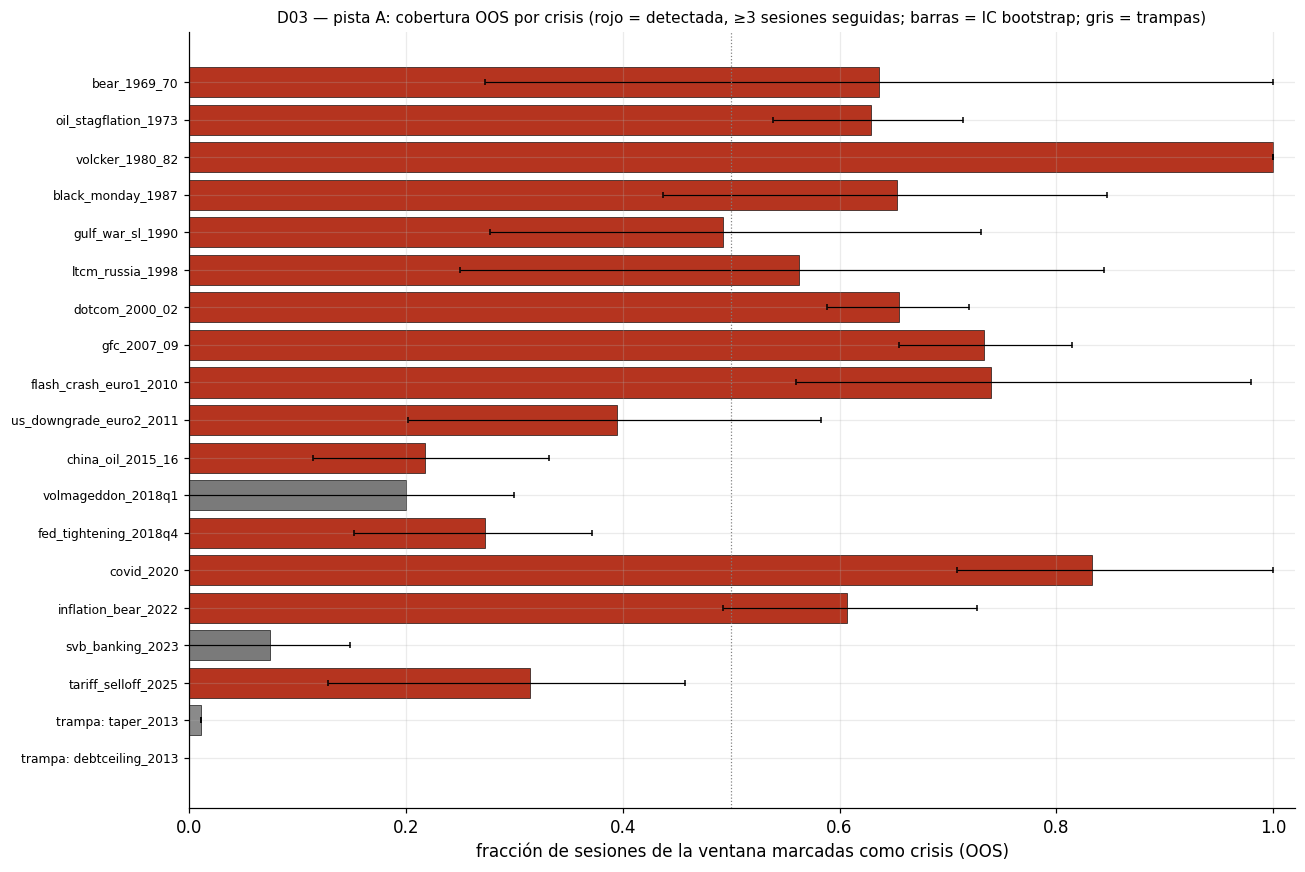

figura -> results/detectores/f2_clustering/D03_B_cobertura_crisis.png


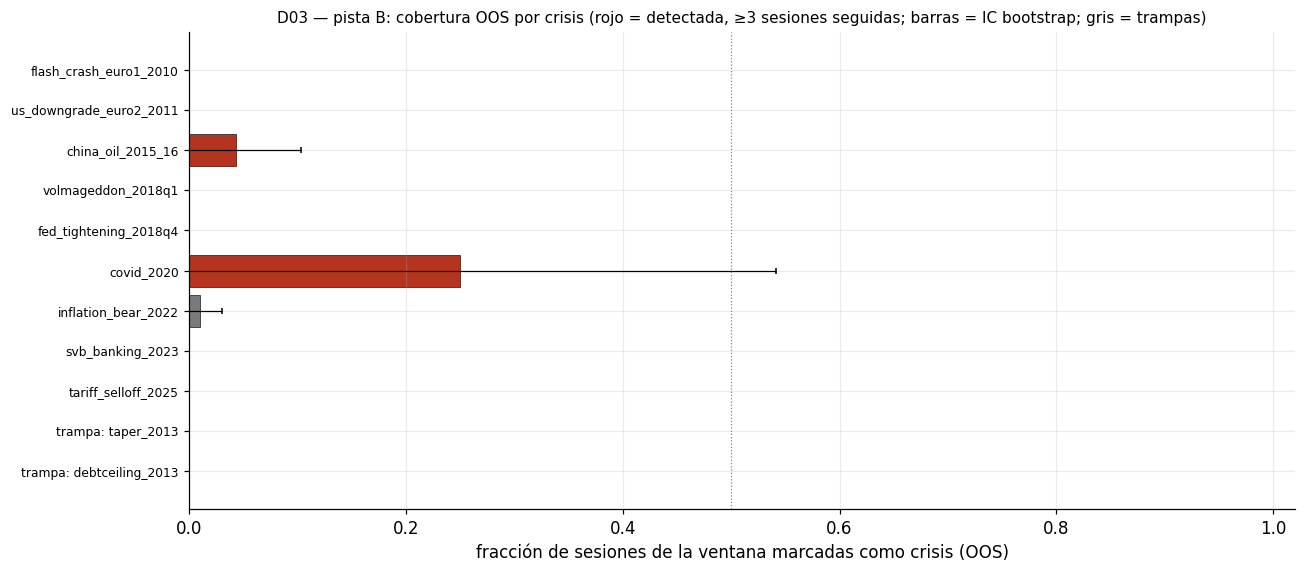

Pista A:


,pico,suelo,cobertura,ic_lo,ic_hi,detectada,lead_lag_dias
crisis,,,,,,,
bear_1969_70,1968-11-29,1970-05-26,0.636,0.273,1.000,1.0,-5.0
oil_stagflation_1973,1973-01-11,1974-10-03,0.629,0.539,0.714,1.0,-216.0
volcker_1980_82,1980-11-28,1982-08-12,1.000,1.000,1.000,1.0,-252.0
black_monday_1987,1987-08-25,1987-12-04,0.653,0.437,0.847,1.0,-220.0
gulf_war_sl_1990,1990-07-16,1990-10-11,0.492,0.277,0.730,1.0,-251.0
ltcm_russia_1998,1998-07-17,1998-08-31,0.562,0.250,0.844,1.0,-212.0
dotcom_2000_02,2000-03-24,2002-10-09,0.655,0.589,0.719,1.0,-252.0
gfc_2007_09,2007-10-09,2009-03-09,0.733,0.654,0.815,1.0,-251.0
flash_crash_euro1_2010,2010-04-23,2010-07-02,0.740,0.560,0.980,1.0,-252.0


Pista B:


,pico,suelo,cobertura,ic_lo,ic_hi,detectada,lead_lag_dias
crisis,,,,,,,
flash_crash_euro1_2010,2010-04-23,2010-07-02,0.000,0.0,0.000,0.0,NaN
us_downgrade_euro2_2011,2011-04-29,2011-10-03,0.000,0.0,0.000,0.0,NaN
china_oil_2015_16,2015-05-21,2016-02-11,0.043,0.0,0.103,1.0,-118.0
volmageddon_2018q1,2018-01-26,2018-02-08,0.000,0.0,0.000,0.0,NaN
fed_tightening_2018q4,2018-09-20,2018-12-24,0.000,0.0,0.000,0.0,NaN
covid_2020,2020-02-19,2020-03-23,0.250,0.0,0.542,1.0,-5.0
inflation_bear_2022,2022-01-03,2022-10-12,0.010,0.0,0.031,0.0,NaN
svb_banking_2023,2023-02-02,2023-03-13,0.000,0.0,0.000,0.0,NaN
tariff_selloff_2025,2025-02-19,2025-04-08,0.000,0.0,0.000,0.0,NaN


In [8]:
TABLAS_COB_D03 = {t: figura_cobertura(t, 'D03') for t in PISTAS}
for t, tab in TABLAS_COB_D03.items():
    print(f'Pista {t}:')
    display(tab.round(3))

In [9]:
display(resumen_ranking(['D03']).round(4))
lectura_detector('D03')

,,puesto_deteccion,de,nivel_etiqueta,score_deteccion,det_event_recall,det_n_detectados,det_n_eventos,det_precision,det_lift_precision,det_base_rate,det_marked_rate,det_mean_crisis_run,mean_crisis_coverage,false_alarm_rate,mean_trap_activation,switching_rate,mean_regime_duration,label_stability,elapsed_seconds
pista,id,,,,,,,,,,,,,,,,,,,
A,D03,3,12,elegible,0.5653,0.8824,15,17,0.4159,2.1444,0.1939,0.3028,7.5485,0.5303,0.5841,0.0053,0.0962,10.3843,0.9832,578.5258
B,D03,10,12,elegible,0.2406,0.2222,2,9,0.2623,1.5188,0.1727,0.0150,6.7778,0.0337,0.7377,0.0000,0.0436,22.8034,0.9370,57.0964


**D03 — GMM (K=3).**

*Pista A* — puesto **3 de 12** (nivel `elegible`), score = 0.565; detecta 15 de 17 crisis OOS (recall por evento 0.88) con precisión diaria 0.42 (2.14× la tasa base 0.19). Marca crisis el 30.3 % de las sesiones, con episodios de crisis de 7.5 sesiones de media y duración media de régimen 10.4; activación en trampas: `taper_2013` 1 %, `debtceiling_2013` 0 %. Mejor cubierta: `volcker_1980_82` (100 %); peor: `svb_banking_2023` (7 %). No detectadas: `volmageddon_2018q1`, `svb_banking_2023`.

*Pista B* — puesto **10 de 12** (nivel `elegible`), score = 0.241; detecta 2 de 9 crisis OOS (recall por evento 0.22) con precisión diaria 0.26 (1.52× la tasa base 0.17). Marca crisis el 1.5 % de las sesiones, con episodios de crisis de 6.8 sesiones de media y duración media de régimen 22.8; activación en trampas: `taper_2013` 0 %, `debtceiling_2013` 0 %. Mejor cubierta: `covid_2020` (25 %); peor: `flash_crash_euro1_2010` (0 %). No detectadas: `flash_crash_euro1_2010`, `us_downgrade_euro2_2011`, `volmageddon_2018q1`, `fed_tightening_2018q4`, `inflation_bear_2022`, `svb_banking_2023`, `tariff_selloff_2025`.

<a id="s4-d09"></a>
### 4.2 D09 — *Statistical Jump Model*

Diagnóstico: como la probabilidad del SJM discreto es *one-hot*, lo informativo es la
**persistencia**: la edad (en sesiones) del régimen vigente cada día OOS. Dientes de sierra largos =
episodios estables; una alfombra de valores bajos = parpadeo. Todo sale del panel OOS causal.

Opcional (`BARRIDO_LAMBDA = True`): barrido **ILUSTRATIVO** in-sample de λ (un ajuste por valor sobre
toda la pista, no causal) para ver cómo λ gobierna el compromiso persistencia ↔ sensibilidad. Tarda
varios minutos por pista, por eso está desactivado.

figura -> results/detectores/f2_clustering/D09_A_estados_oos.png


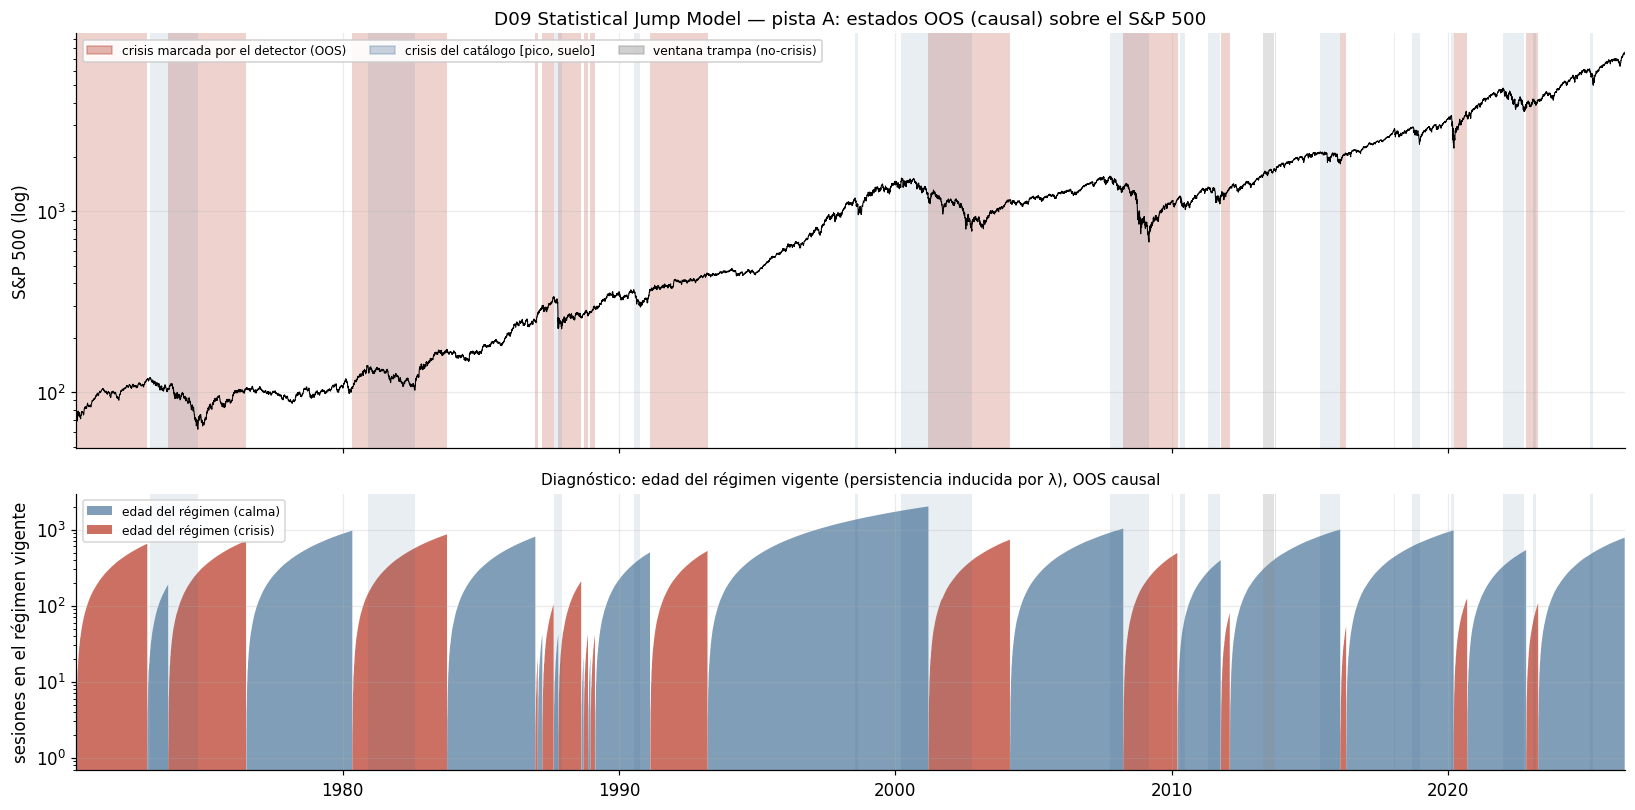

figura -> results/detectores/f2_clustering/D09_B_estados_oos.png


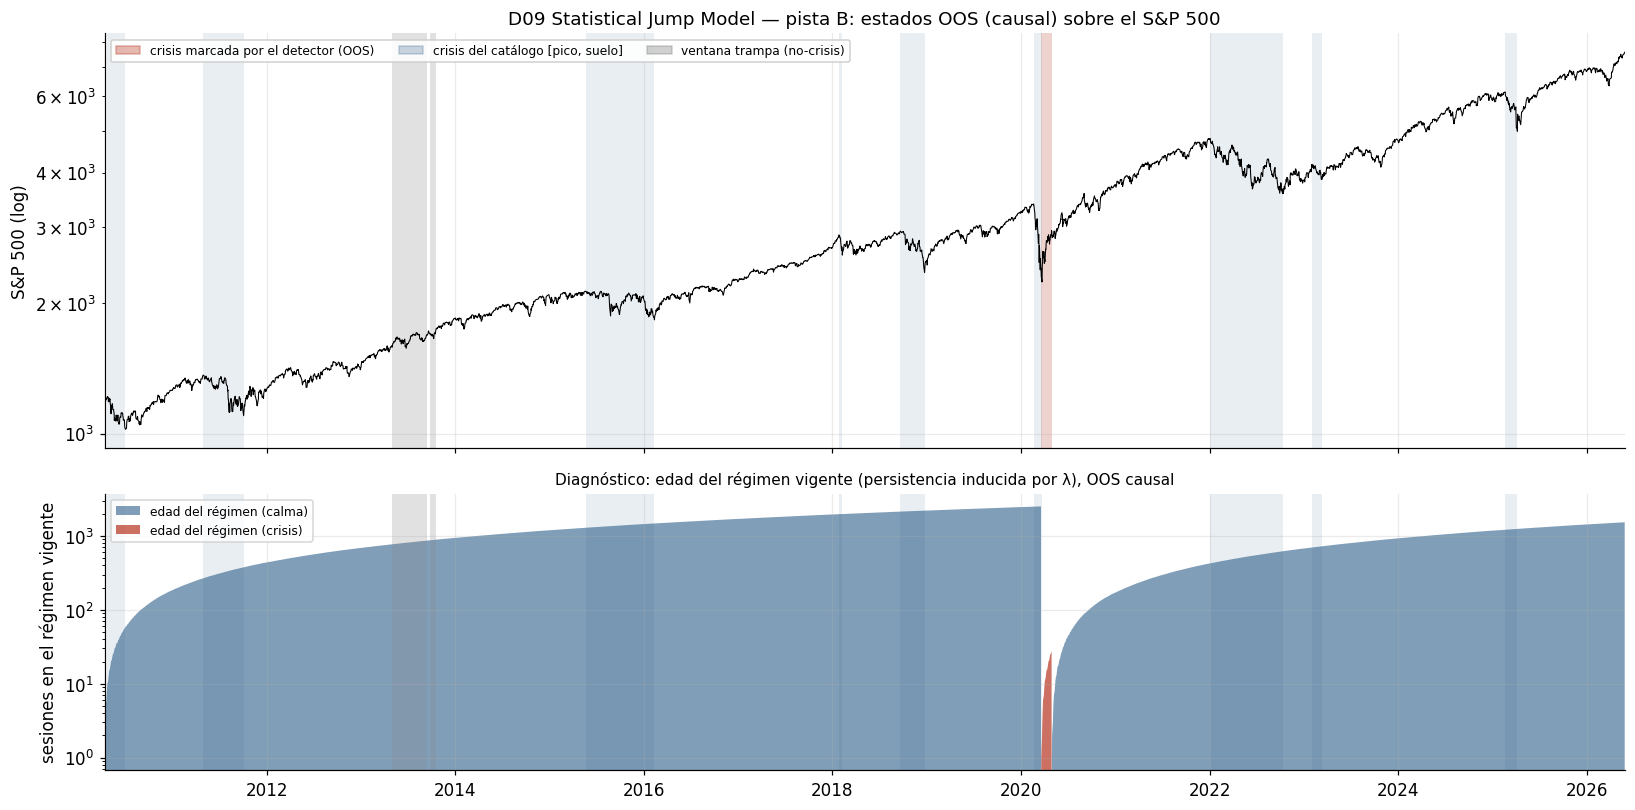

In [10]:
def edad_regimen(estados):
    v = estados.to_numpy()
    edad = np.ones(len(v), dtype=int)
    for i in range(1, len(v)):
        edad[i] = edad[i - 1] + 1 if v[i] == v[i - 1] else 1
    return pd.Series(edad, index=estados.index)


def diag_d09(ax, t, d):
    st = PANELES[(t, d)]['state']
    edad = edad_regimen(st)
    crisis = es_crisis(t, d)
    ax.fill_between(edad.index, 0, edad.where(~crisis).values, color=viz.C_LONG, alpha=0.6, lw=0,
                    label='edad del régimen (calma)')
    ax.fill_between(edad.index, 0, edad.where(crisis).values, color=viz.C_CRISIS, alpha=0.7, lw=0,
                    label='edad del régimen (crisis)')
    ax.set_yscale('log')
    ax.set_ylabel('sesiones en el régimen vigente')
    ax.legend(loc='upper left', fontsize=8)


figura_detector('D09', diag_d09, 'Diagnóstico: edad del régimen vigente (persistencia inducida por λ), OOS causal')

In [11]:
BARRIDO_LAMBDA = False   # True: 6 ajustes in-sample por pista (varios minutos). ILUSTRATIVO, no causal.

if BARRIDO_LAMBDA:
    from regimenes.detectores.f2_clustering.jump_model import JumpModel

    filas = []
    for t in PISTAS:
        s = SPECS[(t, 'D09')]
        X = CTX.matriz(t, s.features)
        for lam in sorted({0.0, 10.0, 25.0, float(s.params['jump_penalty']), 100.0, 200.0}):
            det = JumpModel(**{**s.params, 'jump_penalty': lam}).fit(X)
            det.label_states_economically(X, market_returns=DATOS[t]['SP500_ret'].reindex(X.index))
            st = pd.Series(det.predict(X), index=X.index)
            dur = [x for v in viz.episode_durations(st, det.n_states).values() for x in v]
            filas.append({'pista': t, 'lambda': lam, 'switching_rate': float((st.diff().fillna(0) != 0).mean()),
                          'duracion_media': float(np.mean(dur)),
                          'frac_crisis': float((st == det.crisis_state).mean())})
    BARRIDO = pd.DataFrame(filas).set_index(['pista', 'lambda'])
    display(BARRIDO.round(4))
    fig, axes = plt.subplots(1, len(PISTAS), figsize=(14, 4.5), squeeze=False)
    for ax, t in zip(axes[0], PISTAS):
        b = BARRIDO.loc[t]
        ax.plot(b.index, b['switching_rate'], 'o-', color=viz.C_CRISIS, label='switching_rate')
        ax2 = ax.twinx()
        ax2.plot(b.index, b['duracion_media'], 's--', color=viz.C_LONG, label='duración media')
        ax.axvline(SPECS[(t, 'D09')].params['jump_penalty'], color='grey', lw=1)
        ax.set_xlabel('λ'); ax.set_ylabel('switching_rate'); ax2.set_ylabel('duración media (sesiones)')
        ax.set_title(f'Pista {t}: efecto de λ (ILUSTRATIVO, in-sample)', fontsize=10)
    fig.tight_layout()
    guardar(fig, 'D09_barrido_lambda')
    plt.show()
else:
    print('Barrido de λ desactivado (BARRIDO_LAMBDA = False).')

Barrido de λ desactivado (BARRIDO_LAMBDA = False).


figura -> results/detectores/f2_clustering/D09_A_cobertura_crisis.png


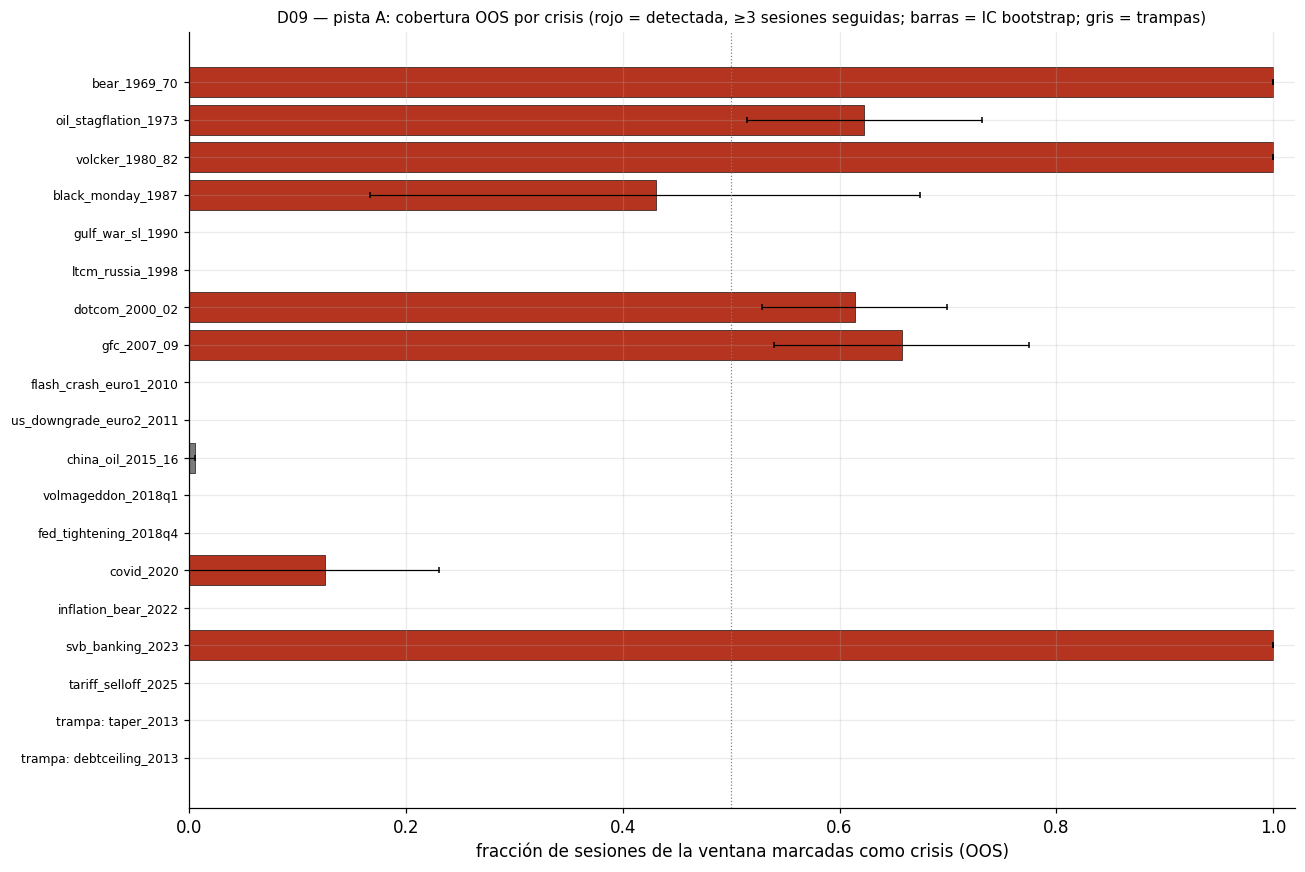

figura -> results/detectores/f2_clustering/D09_B_cobertura_crisis.png


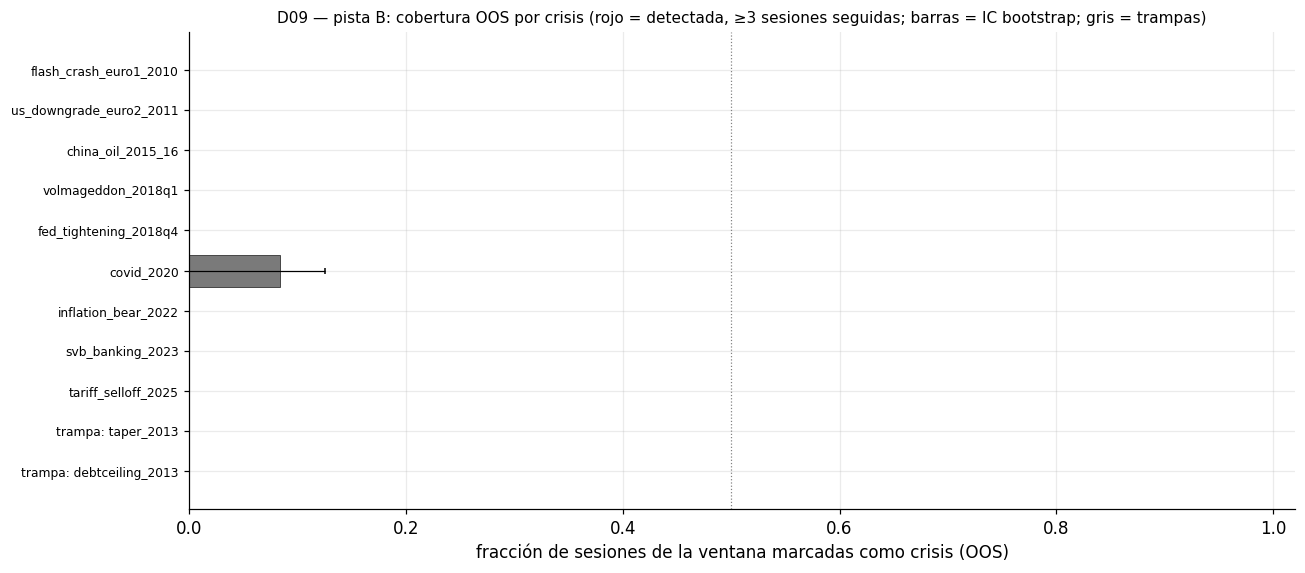

Pista A:


,pico,suelo,cobertura,ic_lo,ic_hi,detectada,lead_lag_dias
crisis,,,,,,,
bear_1969_70,1968-11-29,1970-05-26,1.000,1.000,1.000,1.0,-10.0
oil_stagflation_1973,1973-01-11,1974-10-03,0.622,0.515,0.731,1.0,-252.0
volcker_1980_82,1980-11-28,1982-08-12,1.000,1.000,1.000,1.0,-252.0
black_monday_1987,1987-08-25,1987-12-04,0.431,0.167,0.674,1.0,-240.0
gulf_war_sl_1990,1990-07-16,1990-10-11,0.000,0.000,0.000,0.0,NaN
ltcm_russia_1998,1998-07-17,1998-08-31,0.000,0.000,0.000,0.0,NaN
dotcom_2000_02,2000-03-24,2002-10-09,0.614,0.528,0.699,1.0,-252.0
gfc_2007_09,2007-10-09,2009-03-09,0.657,0.539,0.775,1.0,-233.0
flash_crash_euro1_2010,2010-04-23,2010-07-02,0.000,0.000,0.000,0.0,-252.0


Pista B:


,pico,suelo,cobertura,ic_lo,ic_hi,detectada,lead_lag_dias
crisis,,,,,,,
flash_crash_euro1_2010,2010-04-23,2010-07-02,0.000,0.0,0.000,0.0,NaN
us_downgrade_euro2_2011,2011-04-29,2011-10-03,0.000,0.0,0.000,0.0,NaN
china_oil_2015_16,2015-05-21,2016-02-11,0.000,0.0,0.000,0.0,NaN
volmageddon_2018q1,2018-01-26,2018-02-08,0.000,0.0,0.000,0.0,NaN
fed_tightening_2018q4,2018-09-20,2018-12-24,0.000,0.0,0.000,0.0,NaN
covid_2020,2020-02-19,2020-03-23,0.083,0.0,0.125,0.0,NaN
inflation_bear_2022,2022-01-03,2022-10-12,0.000,0.0,0.000,0.0,NaN
svb_banking_2023,2023-02-02,2023-03-13,0.000,0.0,0.000,0.0,NaN
tariff_selloff_2025,2025-02-19,2025-04-08,0.000,0.0,0.000,0.0,NaN


In [12]:
TABLAS_COB_D09 = {t: figura_cobertura(t, 'D09') for t in PISTAS}
for t, tab in TABLAS_COB_D09.items():
    print(f'Pista {t}:')
    display(tab.round(3))

In [13]:
display(resumen_ranking(['D09']).round(4))
lectura_detector('D09')

,,puesto_deteccion,de,nivel_etiqueta,score_deteccion,det_event_recall,det_n_detectados,det_n_eventos,det_precision,det_lift_precision,det_base_rate,det_marked_rate,det_mean_crisis_run,mean_crisis_coverage,false_alarm_rate,mean_trap_activation,switching_rate,mean_regime_duration,label_stability,elapsed_seconds
pista,id,,,,,,,,,,,,,,,,,,,
A,D09,12,12,elegible,0.3616,0.4706,8,17,0.2936,1.5136,0.1939,0.3379,318.4,0.3209,0.7064,0.0,0.0021,471.1,0.9875,5676.0769
B,D09,11,12,precision_no_supera_azar,0.0000,0.0000,0,9,0.0714,0.4136,0.1727,0.0069,28.0,0.0093,0.9286,0.0,0.0005,1353.0,0.9986,689.1967


**D09 — Statistical Jump Model.**

*Pista A* — puesto **12 de 12** (nivel `elegible`), score = 0.362; detecta 8 de 17 crisis OOS (recall por evento 0.47) con precisión diaria 0.29 (1.51× la tasa base 0.19). Marca crisis el 33.8 % de las sesiones, con episodios de crisis de 318.4 sesiones de media y duración media de régimen 471.1; activación en trampas: `taper_2013` 0 %, `debtceiling_2013` 0 %. Mejor cubierta: `bear_1969_70` (100 %); peor: `gulf_war_sl_1990` (0 %). No detectadas: `gulf_war_sl_1990`, `ltcm_russia_1998`, `flash_crash_euro1_2010`, `us_downgrade_euro2_2011`, `china_oil_2015_16`, `volmageddon_2018q1`, `fed_tightening_2018q4`, `inflation_bear_2022`, `tariff_selloff_2025`.

*Pista B* — puesto **11 de 12** (nivel `precision_no_supera_azar`), score = 0.000; detecta 0 de 9 crisis OOS (recall por evento 0.00) con precisión diaria 0.07 (0.41× la tasa base 0.17). Marca crisis el 0.7 % de las sesiones, con episodios de crisis de 28.0 sesiones de media y duración media de régimen 1353.0; activación en trampas: `taper_2013` 0 %, `debtceiling_2013` 0 %. Mejor cubierta: `covid_2020` (8 %); peor: `flash_crash_euro1_2010` (0 %). No detectadas: `flash_crash_euro1_2010`, `us_downgrade_euro2_2011`, `china_oil_2015_16`, `volmageddon_2018q1`, `fed_tightening_2018q4`, `covid_2020`, `inflation_bear_2022`, `svb_banking_2023`, `tariff_selloff_2025`.

<a id="s4-medias"></a>
### 4.3 Qué caracteriza a cada estado (ILUSTRATIVO)

Un clustering es, literalmente, una partición del espacio de features; su lectura natural es el
**perfil medio de cada estado**. Con **un ajuste único sobre toda la pista** (no causal) se etiquetan
todas las sesiones y se promedian las features estandarizadas por estado, junto con el retorno y la
volatilidad anualizados del S&P 500 en cada estado. Sirve para comprobar que el estado "crisis" es lo
que dice ser (peor retorno, mayor volatilidad, crédito y drawdown deteriorados) y para comparar qué
separa el GMM (con covarianza completa) frente a los centroides del jump model.

figura -> results/detectores/f2_clustering/F2_perfil_de_estados.png


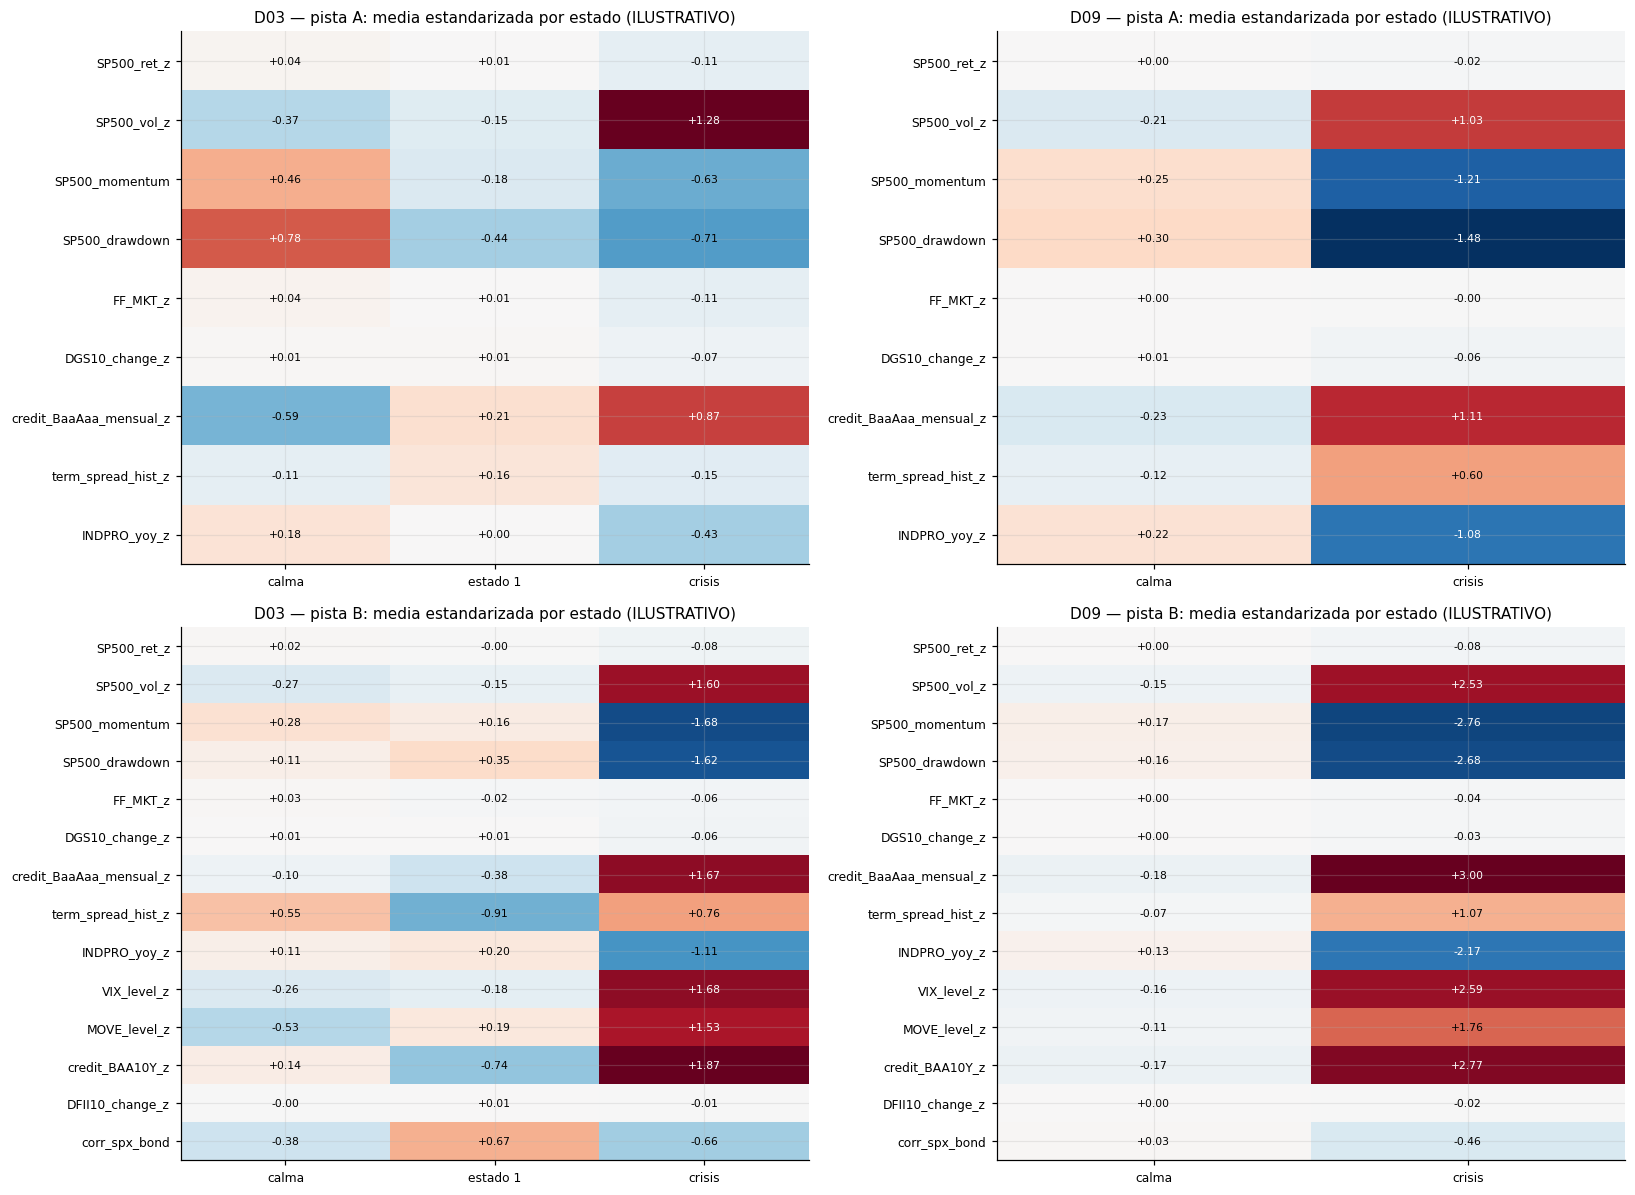

D03 pista A:


,calma,estado 1,crisis
[S&P 500] retorno anual.,0.181,0.084,-0.213
[S&P 500] vol anual.,0.103,0.120,0.319
[fracción de sesiones],0.395,0.440,0.165


D03 pista B:


,calma,estado 1,crisis
[S&P 500] retorno anual.,0.159,0.077,-0.176
[S&P 500] vol anual.,0.141,0.157,0.411
[fracción de sesiones],0.486,0.395,0.119


D09 pista A:


,calma,crisis
[S&P 500] retorno anual.,0.084,0.020
[S&P 500] vol anual.,0.135,0.269
[fracción de sesiones],0.831,0.169


D09 pista B:


,calma,crisis
[S&P 500] retorno anual.,0.102,-0.162
[S&P 500] vol anual.,0.164,0.499
[fracción de sesiones],0.942,0.058


In [14]:
def perfil_estados(t, d):
    det, X = ajuste_ilustrativo(t, d)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        st = pd.Series(det.predict(X), index=X.index)
    Z = (X - X.mean()) / X.std()
    perfil = Z.groupby(st).mean().T
    ret = DATOS[t]['SP500_ret'].reindex(X.index)
    perfil.loc['[S&P 500] retorno anual.'] = ret.groupby(st).mean() * 252
    perfil.loc['[S&P 500] vol anual.'] = ret.groupby(st).std() * np.sqrt(252)
    perfil.loc['[fracción de sesiones]'] = st.value_counts(normalize=True).sort_index()
    nombres = {0: 'calma', det.crisis_state: 'crisis'}
    perfil.columns = [nombres.get(k, f'estado {k}') for k in perfil.columns]
    return perfil


PERFILES = {(t, d): perfil_estados(t, d) for d in DETECTORES for t in PISTAS}
fig, axes = plt.subplots(len(PISTAS), len(DETECTORES), figsize=(15, 11), squeeze=False)
for i, t in enumerate(PISTAS):
    for j, d in enumerate(DETECTORES):
        P = PERFILES[(t, d)]
        inf.dibujar_heatmap(axes[i][j], P.iloc[:-3], cmap='RdBu_r', vmin=None, vmax=None, fmt='{:+.2f}',
                            titulo=f'{d} — pista {t}: media estandarizada por estado (ILUSTRATIVO)')
fig.tight_layout()
guardar(fig, 'F2_perfil_de_estados')
plt.show()
for (t, d), P in PERFILES.items():
    print(f'{d} pista {t}:')
    display(P.iloc[-3:].round(3))

<a id="s5"></a>
## 5. Comparación intra-familia: persistencia frente a cobertura

D03 y D09 comparten features y protocolo, pero no solo difieren en el término temporal: también en
$K$ (§2) y en el modelo de emisión (covarianza completa frente a centroides euclídeos). Las
diferencias que siguen son el efecto conjunto de los tres cambios, no el de λ aislado. La
comparación se lee en tres partes: (i) posición en el ranking ADR-003 y en el plano *recall por evento × precisión
diaria* del banco; (ii) solape de los días marcados en crisis y mapa de cobertura por crisis; (iii)
el compromiso central de la familia: cuánto menos parpadea D09 y qué cobertura pierde frente a D03.

,,puesto_deteccion,de,nivel_etiqueta,score_deteccion,det_event_recall,det_n_detectados,det_n_eventos,det_precision,det_lift_precision,det_base_rate,det_marked_rate,det_mean_crisis_run,mean_crisis_coverage,false_alarm_rate,mean_trap_activation,switching_rate,mean_regime_duration,label_stability,elapsed_seconds
pista,id,,,,,,,,,,,,,,,,,,,
A,D03,3,12,elegible,0.5653,0.8824,15,17,0.4159,2.1444,0.1939,0.3028,7.5485,0.5303,0.5841,0.0053,0.0962,10.3843,0.9832,578.5258
B,D03,10,12,elegible,0.2406,0.2222,2,9,0.2623,1.5188,0.1727,0.0150,6.7778,0.0337,0.7377,0.0000,0.0436,22.8034,0.9370,57.0964
A,D09,12,12,elegible,0.3616,0.4706,8,17,0.2936,1.5136,0.1939,0.3379,318.4000,0.3209,0.7064,0.0000,0.0021,471.1000,0.9875,5676.0769
B,D09,11,12,precision_no_supera_azar,0.0000,0.0000,0,9,0.0714,0.4136,0.1727,0.0069,28.0000,0.0093,0.9286,0.0000,0.0005,1353.0000,0.9986,689.1967


figura -> results/detectores/f2_clustering/F2_comparativa_recall_precision.png


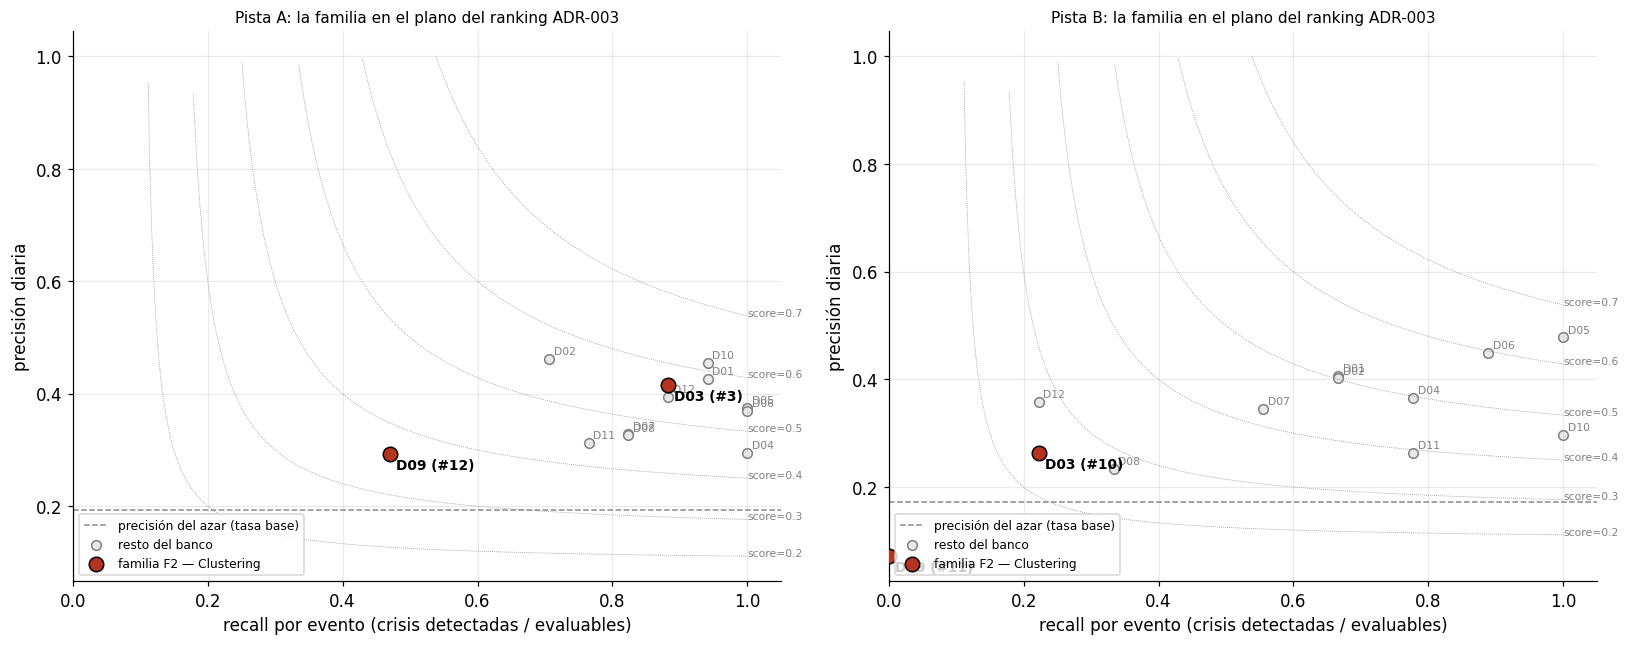

In [15]:
display(resumen_ranking(DETECTORES).round(4))

# Plano recall por evento vs precisión diaria de TODO el banco, con la familia resaltada.
fig, axes = plt.subplots(1, len(PISTAS), figsize=(15, 6), squeeze=False)
for ax, t in zip(axes[0], PISTAS):
    inf.dibujar_plano_ranking(ax, RANKING[RANKING['pista'] == t], DETECTORES, beta=BETA,
                              etiqueta=f'familia {NOMBRE_FAMILIA}',
                              titulo=f'Pista {t}: la familia en el plano del ranking ADR-003')
fig.tight_layout()
guardar(fig, 'F2_comparativa_recall_precision')
plt.show()

figura -> results/detectores/f2_clustering/F2_comparativa_coincidencia_cobertura.png


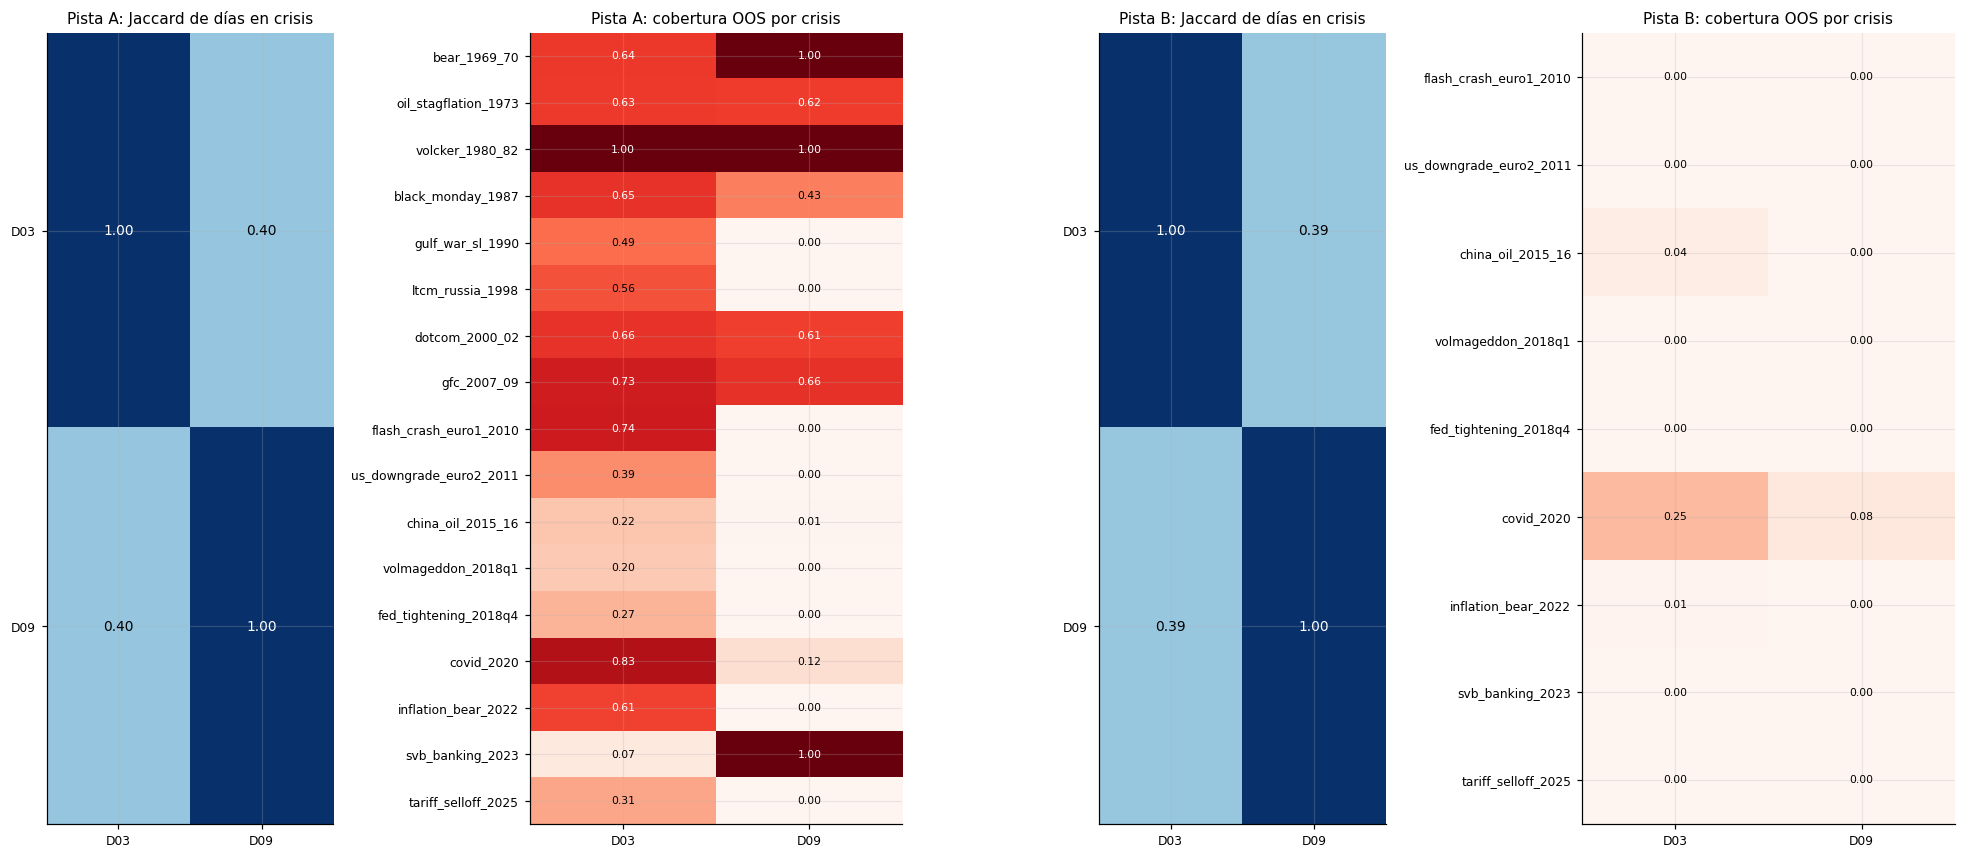

Pista A — índice de Jaccard entre los días marcados crisis:


,D03,D09
D03,1.000,0.398
D09,0.398,1.000


Pista B — índice de Jaccard entre los días marcados crisis:


,D03,D09
D03,1.000,0.391
D09,0.391,1.000


In [16]:
def coincidencia(t):
    return inf.matriz_jaccard({d: es_crisis(t, d) for d in DETECTORES})


def matriz_cobertura(t):
    return pd.DataFrame({d: tabla_cobertura(t, d)['cobertura'] for d in DETECTORES})


COINC = {t: coincidencia(t) for t in PISTAS}
COB = {t: matriz_cobertura(t) for t in PISTAS}
fig, axes = plt.subplots(1, 2 * len(PISTAS), figsize=(18, 0.32 * max(len(c) for c in COB.values()) + 2.5),
                         gridspec_kw={'width_ratios': [1, 1.3] * len(PISTAS)}, squeeze=False)
for i, t in enumerate(PISTAS):
    inf.dibujar_heatmap(axes[0][2 * i], COINC[t], cmap='Blues', fontsize=9,
                        titulo=f'Pista {t}: Jaccard de días en crisis')
    inf.dibujar_heatmap(axes[0][2 * i + 1], COB[t], cmap='Reds',
                        titulo=f'Pista {t}: cobertura OOS por crisis')
fig.tight_layout()
guardar(fig, 'F2_comparativa_coincidencia_cobertura')
plt.show()
for t in PISTAS:
    print(f'Pista {t} — índice de Jaccard entre los días marcados crisis:')
    display(COINC[t].round(3))

figura -> results/detectores/f2_clustering/F2_comparativa_duracion_episodios.png


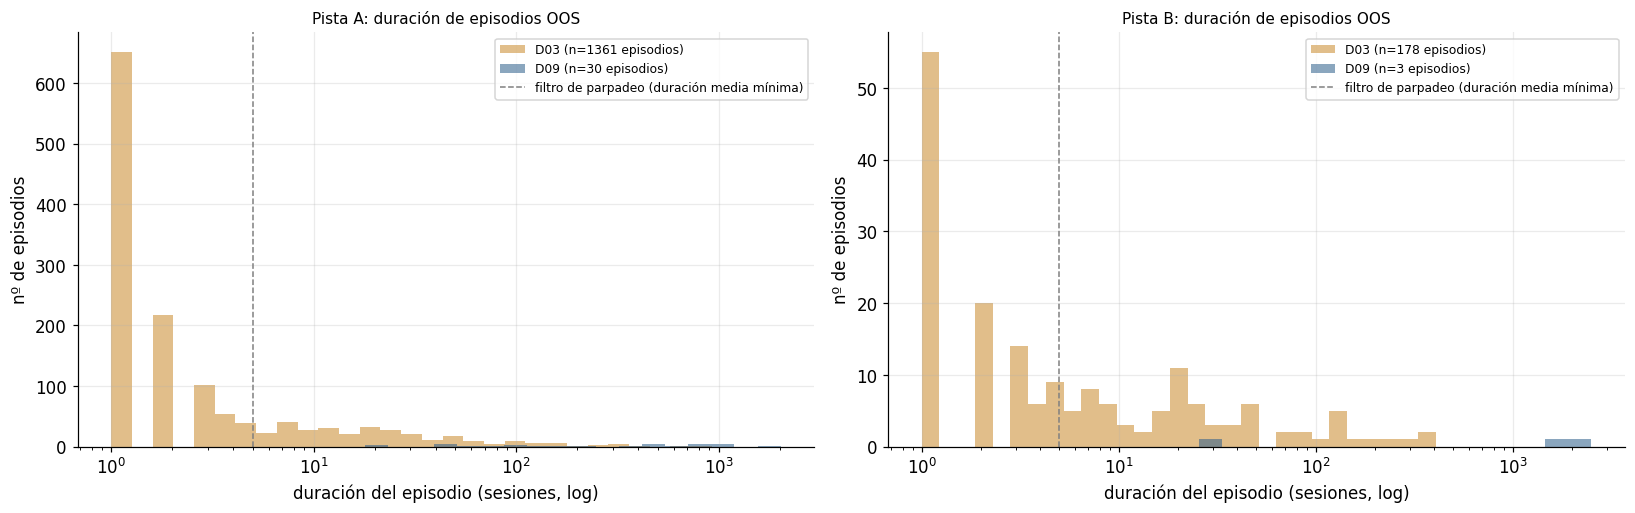

episodios  mediana_duracion  switching_rate  mean_regime_duration  det_mean_crisis_run  mean_crisis_coverage  det_event_recall
pista id                                                                                                                                 
A     D03       1361               2.0          0.0962               10.3843               7.5485                0.5303            0.8824
      D09         30             446.0          0.0021              471.1000             318.4000                0.3209            0.4706
B     D03        178               3.5          0.0436               22.8034               6.7778                0.0337            0.2222
      D09          3            1528.0          0.0005             1353.0000              28.0000                0.0093            0.0000

In [17]:
# (iii) Persistencia vs cobertura: histogramas de duración de episodios OOS D03 vs D09.
fig, axes = plt.subplots(1, len(PISTAS), figsize=(15, 4.8), squeeze=False)
filas = []
for ax, t in zip(axes[0], PISTAS):
    for d, color in zip(DETECTORES, (viz.C_SHORT, viz.C_LONG)):
        st = PANELES[(t, d)]['state']
        dur = [x for v in viz.episode_durations(st, int(METRICAS.loc[(t, d), 'n_states'])).values() for x in v]
        ax.hist(dur, bins=np.logspace(0, np.log10(max(dur) + 1), 30), alpha=0.55, color=color,
                label=f'{d} (n={len(dur)} episodios)')
        filas.append({'pista': t, 'id': d, 'episodios': len(dur), 'mediana_duracion': float(np.median(dur)),
                      'switching_rate': METRICAS.loc[(t, d), 'switching_rate'],
                      'mean_regime_duration': METRICAS.loc[(t, d), 'mean_regime_duration'],
                      'det_mean_crisis_run': METRICAS.loc[(t, d), 'det_mean_crisis_run'],
                      'mean_crisis_coverage': RANK.loc[(t, d), 'mean_crisis_coverage'],
                      'det_event_recall': RANK.loc[(t, d), 'det_event_recall']})
    ax.set_xscale('log')
    ax.axvline(rk.DETECTION_DEFAULTS['min_mean_duration'], color='grey', ls='--', lw=1,
               label='filtro de parpadeo (duración media mínima)')
    ax.set_xlabel('duración del episodio (sesiones, log)')
    ax.set_ylabel('nº de episodios')
    ax.set_title(f'Pista {t}: duración de episodios OOS', fontsize=10)
    ax.legend(fontsize=8)
fig.tight_layout()
guardar(fig, 'F2_comparativa_duracion_episodios')
plt.show()
PERSIST = pd.DataFrame(filas).set_index(['pista', 'id'])
display(PERSIST.round(4))

In [18]:
lineas = []
for t in PISTAS:
    a, b = PERSIST.loc[(t, 'D03')], PERSIST.loc[(t, 'D09')]
    ratio_sw = a.switching_rate / b.switching_rate if b.switching_rate > 0 else np.inf
    ratio_dur = b.mean_regime_duration / a.mean_regime_duration
    lineas.append(
        f"- **Pista {t}** (D03 K={SPECS[(t, 'D03')].params['n_states']} GMM → D09 "
        f"K={SPECS[(t, 'D09')].params['n_states']} con λ): el switching baja {ratio_sw:.1f}× "
        f'({a.switching_rate:.4f} → {b.switching_rate:.4f}) '
        f'y la duración media de régimen se multiplica por {ratio_dur:.1f} ({a.mean_regime_duration:.1f} → '
        f'{b.mean_regime_duration:.1f} sesiones). Cobertura media de crisis {a.mean_crisis_coverage:.2f} → '
        f'{b.mean_crisis_coverage:.2f}; recall por evento {a.det_event_recall:.2f} → {b.det_event_recall:.2f}. '
        f"Ranking: D03 #{int(RANK.loc[(t, 'D03'), 'puesto_deteccion'])} (`{RANK.loc[(t, 'D03'), 'nivel_etiqueta']}`) "
        f"vs D09 #{int(RANK.loc[(t, 'D09'), 'puesto_deteccion'])} (`{RANK.loc[(t, 'D09'), 'nivel_etiqueta']}`).")
lineas.append('- *Atribución:* las diferencias combinan λ, el número de estados y el modelo de emisión; '
              'no miden el efecto de la persistencia por sí sola.')
display(Markdown('\n'.join(lineas)))

- **Pista A** (D03 K=3 GMM → D09 K=2 con λ): el switching baja 46.9× (0.0962 → 0.0021) y la duración media de régimen se multiplica por 45.4 (10.4 → 471.1 sesiones). Cobertura media de crisis 0.53 → 0.32; recall por evento 0.88 → 0.47. Ranking: D03 #3 (`elegible`) vs D09 #12 (`elegible`).
- **Pista B** (D03 K=3 GMM → D09 K=2 con λ): el switching baja 88.5× (0.0436 → 0.0005) y la duración media de régimen se multiplica por 59.3 (22.8 → 1353.0 sesiones). Cobertura media de crisis 0.03 → 0.01; recall por evento 0.22 → 0.00. Ranking: D03 #10 (`elegible`) vs D09 #11 (`precision_no_supera_azar`).
- *Atribución:* las diferencias combinan λ, el número de estados y el modelo de emisión; no miden el efecto de la persistencia por sí sola.

In [19]:
lineas = []
for t in PISTAS:
    r = RANK.loc[[(t, d) for d in DETECTORES]].sort_values('puesto_deteccion')
    mejor = r.index[0][1]
    J = COINC[t].where(~np.eye(len(DETECTORES), dtype=bool))
    a, b = J.stack().idxmax()
    cob = COB[t]
    comun = cob.index[(cob > 0.5).all(axis=1)].tolist()
    ninguno = cob.index[(cob < 0.1).all(axis=1)].tolist()
    lineas.append(
        f'- **Pista {t}**: orden intra-familia '
        + ' > '.join(f"{d} (#{int(RANK.loc[(t, d), 'puesto_deteccion'])})" for _, d in r.index)
        + f'; el mejor de la familia es **{mejor}** con score {RANK.loc[(t, mejor), "score_deteccion"]:.3f}. '
        f'Par más redundante: {a}–{b} (Jaccard {J.loc[a, b]:.2f}). '
        f'Crisis cubiertas >50 % por todos: {", ".join(comun) or "ninguna"}; '
        f'crisis que ninguno cubre >10 %: {", ".join(ninguno) or "ninguna"}.')
display(Markdown('\n'.join(lineas)))

- **Pista A**: orden intra-familia D03 (#3) > D09 (#12); el mejor de la familia es **D03** con score 0.565. Par más redundante: D03–D09 (Jaccard 0.40). Crisis cubiertas >50 % por todos: bear_1969_70, oil_stagflation_1973, volcker_1980_82, dotcom_2000_02, gfc_2007_09; crisis que ninguno cubre >10 %: ninguna.
- **Pista B**: orden intra-familia D03 (#10) > D09 (#11); el mejor de la familia es **D03** con score 0.241. Par más redundante: D03–D09 (Jaccard 0.39). Crisis cubiertas >50 % por todos: ninguna; crisis que ninguno cubre >10 %: flash_crash_euro1_2010, us_downgrade_euro2_2011, china_oil_2015_16, volmageddon_2018q1, fed_tightening_2018q4, inflation_bear_2022, svb_banking_2023, tariff_selloff_2025.

<a id="s6"></a>
## 6. Hallazgos de la Capa 1 (v1) y qué se mantiene o cambia en v2

**Lo que concluyó la Capa 1** (notebooks congelados en el tag git `capa1-final`:
`capa1-final:capa1_exploracion/notebooks/03_clustering_gmm.ipynb` y `09_jump_model.ipynb`,
p. ej. `git show capa1-final:capa1_exploracion/notebooks/03_clustering_gmm.ipynb`; cifras v1 en
`docs/historia/capa1/resultados/`;
fichas `docs/detectores/D03_*.md` y `D09_*.md`; cifras en la celda siguiente):

- **D03** fijó K por BIC *in-sample* (el valor que conserva el registro, §2; usado solo como guía y
  declarado como fuga potencial) y
  mostró las tres predicciones de la hipótesis del CHECKPOINT 2 (citada literalmente en §6.1): **capta estructura de correlación** (buena cobertura de
  COVID e inflación 2022 gracias a la covarianza completa), **parpadeo severo** (rachas de pocos días) y
  **causalidad solo por el walk-forward**. La estabilidad de etiquetas entre reajustes era alta: el
  parpadeo es intra-secuencia, no inestabilidad entre folds. Veredicto: baseline interpretable, no
  detector operativo.
- **D09** con λ alto redujo drásticamente el switching y multiplicó la duración de
  los episodios frente a D03 con las **mismas** features: la persistencia se puede imponer sin
  dinámica de Markov. El precio fue la **cobertura de crisis lentas o poco extremas** (la inflación de
  2022 casi desaparecía, COVID bajaba): λ actúa como un filtro paso-bajo sobre la secuencia de
  estados. Verificado que `predict_online` es causal (añadir futuro no cambia etiquetas). Frente al
  autoencoder (D12) resultó mucho más limpio.
- En v1 ambos tenían la GFC, 2011 y el taper de 2013 **dentro del train** (features desde 2007): esos
  episodios no eran evaluables OOS.

**Qué cambia en v2 (sin cambiar los detectores congelados):**

| aspecto | Capa 1 (v1) | v2 |
|---|---|---|
| features | panel v1 de features causales (desde 2007) | núcleo de la pista: `CORE_A` (A) o `CORE_B` (B) del registro, ver §2 |
| ventana | un único tramo 2007+ | pista A (histórica, desde 1962: la GFC y 2011 pasan a ser OOS) y pista B (multi-activo) |
| semilla | defecto del constructor | `SEED` explícita en el registro y en la huella de caché (ADR-003) |
| protocolo | predicción online por bloque sin contexto | contexto antepuesto al bloque (ADR-003) |
| juez | cobertura de 4 crisis y 2 trampas | recall por evento × precisión diaria sobre el catálogo completo de la pista y filtros de parpadeo (ADR-003) |

In [20]:
V1 = pd.read_csv(V1_MASTER).set_index('detector')
COLS_V1 = ['ventana_eval', 'cov_GFC_2008', 'cov_EuroDebt_2011', 'cov_COVID_2020', 'cov_Inflation_2022',
           'fa_TaperTantrum_2013', 'fa_Selloff_Q4_2018', 'false_alarm_rate', 'switching_rate',
           'mean_regime_duration', 'label_stability']
tabla_v1 = V1.loc[[V1_NOMBRE[d] for d in DETECTORES], COLS_V1]
tabla_v1.index = [f'{d} ({V1_NOMBRE[d]})' for d in DETECTORES]
print(f'Métricas de la Capa 1 (v1) — {rel(V1_MASTER)}:')
display(tabla_v1.round(3))

# Mismos conceptos en v1 y v2 (OJO: las ventanas v2 son [pico, suelo] del catálogo y difieren de las v1).
MAPA_V1_V2 = {
    'cov_GFC_2008': 'cov_gfc_2007_09',
    'cov_EuroDebt_2011': 'cov_us_downgrade_euro2_2011',
    'cov_COVID_2020': 'cov_covid_2020',
    'cov_Inflation_2022': 'cov_inflation_bear_2022',
    'fa_Selloff_Q4_2018': 'cov_fed_tightening_2018q4',   # v1: trampa -> v2: crisis del catálogo
    'fa_TaperTantrum_2013': 'fa_taper_2013',
    'false_alarm_rate': 'false_alarm_rate',
    'switching_rate': 'switching_rate',
    'mean_regime_duration': 'mean_regime_duration',
    'label_stability': 'label_stability',
}
filas = []
for d in DETECTORES:
    for c1, c2 in MAPA_V1_V2.items():
        fila = {'id': d, 'v1': c1, 'v2': c2, 'valor_v1': V1.loc[V1_NOMBRE[d], c1]}
        for t in PISTAS:
            fila[f'v2_pista_{t}'] = METRICAS.loc[(t, d)].get(c2, np.nan)
        filas.append(fila)
V1_V2 = pd.DataFrame(filas).set_index(['id', 'v1'])
print('Comparación v1 -> v2 (NaN = fuera del tramo OOS):')
display(V1_V2.round(3))
for d in DETECTORES:
    print(f"{d}: ventana OOS v1 {V1.loc[V1_NOMBRE[d], 'ventana_eval']} | "
          + ' | '.join(f"v2-{t} {METRICAS.loc[(t, d), 'ventana_eval']}" for t in PISTAS))

Métricas de la Capa 1 (v1) — docs/historia/capa1/resultados/metrics_master.csv:


,ventana_eval,cov_GFC_2008,cov_EuroDebt_2011,cov_COVID_2020,cov_Inflation_2022,fa_TaperTantrum_2013,fa_Selloff_Q4_2018,false_alarm_rate,switching_rate,mean_regime_duration,label_stability
D03 (clustering_gmm_k3),2015-09-15→2026-06-12 (n=2649),NaN,NaN,0.96,0.865,NaN,0.0,0.494,0.126,7.907,0.976
D09 (jump_model),2015-09-15→2026-06-12 (n=2649),NaN,NaN,0.72,0.168,NaN,0.0,0.624,0.005,176.600,0.983


Comparación v1 -> v2 (NaN = fuera del tramo OOS):


v2  valor_v1  v2_pista_A  v2_pista_B
id  v1                                                                                 
D03 cov_GFC_2008                      cov_gfc_2007_09       NaN       0.733         NaN
    cov_EuroDebt_2011     cov_us_downgrade_euro2_2011       NaN       0.394       0.000
    cov_COVID_2020                     cov_covid_2020     0.960       0.833       0.250
    cov_Inflation_2022        cov_inflation_bear_2022     0.865       0.607       0.010
    fa_Selloff_Q4_2018      cov_fed_tightening_2018q4     0.000       0.273       0.000
    fa_TaperTantrum_2013                fa_taper_2013       NaN       0.011       0.000
    false_alarm_rate                 false_alarm_rate     0.494       0.584       0.738
    switching_rate                     switching_rate     0.126       0.096       0.044
    mean_regime_duration         mean_regime_duration     7.907      10.384      22.803
    label_stability                   label_stability     0.976       0.983       0.937
D09 cov_GFC_2008                      cov_gfc_2007_09       NaN       0.657         NaN
    cov_EuroDebt_2011     cov_us_downgrade_euro2_2011       NaN       0.000       0.000
    cov_COVID_2020                     cov_covid_2020     0.720       0.125       0.083
    cov_Inflation_2022        cov_inflation_bear_2022     0.168       0.000       0.000
    fa_Selloff_Q4_2018      cov_fed_tightening_2018q4     0.000       0.000       0.000
    fa_TaperTantrum_2013                fa_taper_2013       NaN       0.000       0.000
    false_alarm_rate                 false_alarm_rate     0.624       0.706       0.929
    switching_rate                     switching_rate     0.005       0.002       0.000
    mean_regime_duration         mean_regime_duration   176.600     471.100    1353.000
    label_stability                   label_stability     0.983       0.988       0.999

D03: ventana OOS v1 2015-09-15→2026-06-12 (n=2649) | v2-A 1970-05-12→2026-05-29 (n=14133) | v2-B 2010-04-12→2026-05-29 (n=4059)
D09: ventana OOS v1 2015-09-15→2026-06-12 (n=2649) | v2-A 1970-05-12→2026-05-29 (n=14133) | v2-B 2010-04-12→2026-05-29 (n=4059)


In [21]:
v1 = lambda d, col: V1.loc[V1_NOMBRE[d], col]
v2 = lambda t, d, col: METRICAS.loc[(t, d)].get(col, np.nan)
pct = lambda x: 'fuera del OOS' if pd.isna(x) else f'{100 * x:.0f} %'
lineas = []

# H1: λ reduce drásticamente el parpadeo frente al GMM.
r1 = v1('D03', 'switching_rate') / v1('D09', 'switching_rate')
lineas.append(f"- **Parpadeo** — v1: switching D03 {v1('D03', 'switching_rate'):.4f} vs D09 "
              f"{v1('D09', 'switching_rate'):.4f} ({r1:.0f}×). v2: " + '; '.join(
    f"pista {t}: {v2(t, 'D03', 'switching_rate'):.4f} vs {v2(t, 'D09', 'switching_rate'):.4f}"
    f" ({v2(t, 'D03', 'switching_rate') / v2(t, 'D09', 'switching_rate'):.0f}×)"
    f" → {'se mantiene' if v2(t, 'D09', 'switching_rate') < v2(t, 'D03', 'switching_rate') else 'NO se mantiene'}"
    for t in PISTAS) + '.')

# H2: el precio es la cobertura de crisis lentas (inflación 2022).
lineas.append(f"- **Inflación 2022** — v1: D03 {pct(v1('D03', 'cov_Inflation_2022'))} vs D09 "
              f"{pct(v1('D09', 'cov_Inflation_2022'))}. v2: " + '; '.join(
    f"pista {t}: D03 {pct(v2(t, 'D03', 'cov_inflation_bear_2022'))} vs D09 {pct(v2(t, 'D09', 'cov_inflation_bear_2022'))}"
    f" → {'se mantiene' if v2(t, 'D09', 'cov_inflation_bear_2022') < v2(t, 'D03', 'cov_inflation_bear_2022') else 'NO se mantiene'}"
    for t in PISTAS) + '.')

# H3: COVID.
lineas.append(f"- **COVID 2020** — v1: D03 {pct(v1('D03', 'cov_COVID_2020'))} vs D09 {pct(v1('D09', 'cov_COVID_2020'))}. v2: "
              + '; '.join(f"pista {t}: D03 {pct(v2(t, 'D03', 'cov_covid_2020'))} vs D09 {pct(v2(t, 'D09', 'cov_covid_2020'))}"
                          for t in PISTAS) + '.')

# H4: con la ventana larga, la GFC pasa a ser OOS en v2.
lineas.append(f"- **GFC** — v1: D03 {pct(v1('D03', 'cov_GFC_2008'))}, D09 {pct(v1('D09', 'cov_GFC_2008'))}. v2: "
              + '; '.join(f"pista {t}: D03 {pct(v2(t, 'D03', 'cov_gfc_2007_09'))}, D09 {pct(v2(t, 'D09', 'cov_gfc_2007_09'))}"
                          for t in PISTAS) + '.')

# H5: ¿sigue D03 cayendo en el filtro de parpadeo de ADR-003?
lineas.append('- **Nivel ADR-003** (precisión por encima del azar y filtros de parpadeo: duración media de régimen ≥ '
              f"{rk.DETECTION_DEFAULTS['min_mean_duration']:g} y episodios de crisis ≥ {rk.DETECTION_DEFAULTS['min_crisis_run']:g}): "
              + '; '.join(f"pista {t}: " + ', '.join(f"{d} `{RANK.loc[(t, d), 'nivel_etiqueta']}`" for d in DETECTORES)
                          for t in PISTAS) + '.')
display(Markdown('\n'.join(lineas)))

- **Parpadeo** — v1: switching D03 0.1261 vs D09 0.0053 (24×). v2: pista A: 0.0962 vs 0.0021 (47×) → se mantiene; pista B: 0.0436 vs 0.0005 (89×) → se mantiene.
- **Inflación 2022** — v1: D03 87 % vs D09 17 %. v2: pista A: D03 61 % vs D09 0 % → se mantiene; pista B: D03 1 % vs D09 0 % → se mantiene.
- **COVID 2020** — v1: D03 96 % vs D09 72 %. v2: pista A: D03 83 % vs D09 12 %; pista B: D03 25 % vs D09 8 %.
- **GFC** — v1: D03 fuera del OOS, D09 fuera del OOS. v2: pista A: D03 73 %, D09 66 %; pista B: D03 fuera del OOS, D09 fuera del OOS.
- **Nivel ADR-003** (precisión por encima del azar y filtros de parpadeo: duración media de régimen ≥ 5 y episodios de crisis ≥ 3): pista A: D03 `elegible`, D09 `elegible`; pista B: D03 `elegible`, D09 `precision_no_supera_azar`.

<a id="s6-cp2"></a>
### 6.1 Hipótesis del CHECKPOINT 2 y veredicto (v1 → v2)

Hipótesis citadas literalmente de la cabecera de los notebooks v1 (`03_clustering_gmm.ipynb` y
`09_jump_model.ipynb`, tag git `capa1-final`) y de la ficha `docs/detectores/D09_jump_model.md`.
Las cifras que el texto v1 incluía se omiten aquí («[…]»). Las genera la celda siguiente, junto
con la lectura v2.

- **D03 — hipótesis v1:** *«captará regímenes con estructura de correlación distinta (gracias a
  la covarianza full); fallará por flickering severo —parpadeo de las etiquetas de un día para
  otro, al no haber persistencia—; y no es causal de forma nativa»* (la causalidad se la impone
  el `walk_forward`, no el modelo).
  **Veredicto v1: consistente con las tres predicciones.** Captaba COVID e inflación 2022 con
  cobertura alta gracias a la covarianza completa y mostraba un parpadeo severo, con rachas de
  pocos días. Era causal solo por el walk-forward. Quedó como **baseline no temporal
  interpretable, no como detector operativo**.
- **D09 — hipótesis v1** (notebook): *«frente a D3 (GMM estático, sin término temporal […] →
  flickering alto), D9 debe dar MENOS switching y MAYOR duración media gracias a λ. La pregunta
  del TFM no es solo si lo consigue, sino **a qué precio**: ¿conserva la cobertura de crisis o la
  persistencia se paga sacrificando la detección de shocks rápidos?»*. En la ficha: *«Histéresis
  aprendida: estados persistentes, online, menos flickering, drawdowns suaves; rival honesto del
  AE+clustering en muestra pequeña.»*
  **Veredicto v1: se cumple en lo esencial, con un matiz.** La persistencia, el carácter online y
  el menor parpadeo se confirmaron con rotundidad. El precio fue **perder cobertura** de las crisis
  lentas (la inflación de 2022 casi desaparecía) y bajar en COVID: λ actúa como un filtro paso-bajo
  sobre la secuencia de estados. Frente al autoencoder (D12), D9 era mucho más limpio. La
  conclusión v1 **separaba los usos**:
  - **D9**, cuando domina el coste de conmutar (turnover, señales de asignación) y la crisis
    objetivo es persistente.
  - **D3**, para la **alarma temprana de shocks rápidos** (COVID), donde la sensibilidad pesa más
    que la estabilidad de la etiqueta.

**Qué dice v2.** La celda siguiente comprueba cuatro cosas con los núcleos `CORE_A`/`CORE_B`:

- si D03 sigue parpadeando y cómo lo trata el filtro de persistencia ADR-003;
- si D09 sigue reduciendo el *switching* y alargando los episodios frente a D03;
- si el precio en cobertura (2022, COVID, recall por evento) se mantiene;
- si el reparto de usos sigue en pie: D03 más sensible en el shock rápido de COVID, D09 más
  limpio que D12.

Dos cautelas de lectura. (i) La comparación D03/D09 no aísla λ: también cambian $K$ y el modelo
de emisión (§5), así que «precio de la persistencia» debe leerse como «diferencia D09 − D03».
(ii) El lead/lag frente al suelo (`metricas.lead_lag`) toma el **primer** cruce sostenido de
`p_crisis` en las sesiones previas al suelo: un valor anterior al pico de la crisis indica una
alarma que ya estaba encendida (o una activación previa), no anticipación. Por eso la
sensibilidad al shock rápido se juzga con la cobertura, y el lead/lag solo se muestra con su
lectura (saturado / antes del pico / entre pico y suelo).

In [22]:
# Hipótesis del CHECKPOINT 2 (v1) frente a v2. Cifras v1: CSV maestro archivado (V1, §6);
# cifras v2: caché verificada del benchmark (METRICAS) y ranking ADR-003 (RANK, todas las familias).
cp1 = lambda d, col: V1.loc[V1_NOMBRE[d], col]
cp2 = lambda t, d, col: METRICAS.loc[(t, d)].get(col, np.nan)
pct = lambda x: 'fuera del OOS' if pd.isna(x) else f'{100 * float(x):.0f} %'
puesto = lambda t, d: (f"{int(RANK.loc[(t, d), 'puesto_deteccion'])}º de {int(N_PISTA[t])} "
                       f"(`{RANK.loc[(t, d), 'nivel_etiqueta']}`)")
ll = lambda x: 'sin activación' if pd.isna(x) else f'{float(x):+.0f}'


def lectura_ll(t, d, crisis):
    """lead/lag de una crisis con su lectura (inf.clasificar_lead_lag)."""
    tab = inf.clasificar_lead_lag(tabla_cobertura(t, d), PANELES[(t, d)].index)
    if crisis not in tab.index:
        return 'fuera del OOS'
    f = tab.loc[crisis]
    return f"{ll(f['lead_lag_dias'])} ({f['lectura_lead_lag']}; pico→suelo {int(f['sesiones_pico_suelo'])} sesiones)"


lineas = []

# D03 — «estructura de correlación (cov. full); flickering severo; causal solo por walk-forward».
lineas.append(
    f"- **D03** — v1: COVID {pct(cp1('D03', 'cov_COVID_2020'))}, 2022 {pct(cp1('D03', 'cov_Inflation_2022'))}; "
    f"switching {cp1('D03', 'switching_rate'):.4f}, duración media {cp1('D03', 'mean_regime_duration'):.1f} sesiones.")
for t in PISTAS:
    lineas.append(
        f"  - v2 pista {t}: COVID {pct(cp2(t, 'D03', 'cov_covid_2020'))}, 2022 "
        f"{pct(cp2(t, 'D03', 'cov_inflation_bear_2022'))}; switching {cp2(t, 'D03', 'switching_rate'):.4f}, "
        f"duración media {cp2(t, 'D03', 'mean_regime_duration'):.1f} sesiones (filtro ADR-003: ≥ "
        f"{rk.DETECTION_DEFAULTS['min_mean_duration']:g}) → "
        + ('sigue parpadeando por debajo del filtro' if cp2(t, 'D03', 'mean_regime_duration')
           < rk.DETECTION_DEFAULTS['min_mean_duration'] else 'pasa el filtro de persistencia')
        + f"; puesto {puesto(t, 'D03')}.")

# D09 — «menos switching y más duración que D3; ¿a qué precio en cobertura?».
lineas.append(
    f"- **D09** — v1: switching D03/D09 = {cp1('D03', 'switching_rate') / cp1('D09', 'switching_rate'):.0f}×, "
    f"duración media D09/D03 = {cp1('D09', 'mean_regime_duration') / cp1('D03', 'mean_regime_duration'):.0f}×; "
    f"precio: 2022 D09 {pct(cp1('D09', 'cov_Inflation_2022'))} vs D03 {pct(cp1('D03', 'cov_Inflation_2022'))}, "
    f"COVID D09 {pct(cp1('D09', 'cov_COVID_2020'))} vs D03 {pct(cp1('D03', 'cov_COVID_2020'))}; frente al AE: "
    f"switching D09 {cp1('D09', 'switching_rate'):.4f} vs D12 {V1.loc['deep_ae_regime', 'switching_rate']:.4f}.")
for t in PISTAS:
    s3, s9 = cp2(t, 'D03', 'switching_rate'), cp2(t, 'D09', 'switching_rate')
    r3, r9 = cp2(t, 'D03', 'det_event_recall'), cp2(t, 'D09', 'det_event_recall')
    c3, c9 = cp2(t, 'D03', 'cov_covid_2020'), cp2(t, 'D09', 'cov_covid_2020')
    texto = (
        f"  - v2 pista {t}: switching D03/D09 = {s3 / s9:.0f}×, duración media D09/D03 = "
        f"{cp2(t, 'D09', 'mean_regime_duration') / cp2(t, 'D03', 'mean_regime_duration'):.0f}× → "
        + ('la persistencia se mantiene' if s9 < s3 else 'la persistencia NO se mantiene')
        + f"; precio: recall por evento D09 {r9:.2f} vs D03 {r3:.2f}, 2022 D09 "
        f"{pct(cp2(t, 'D09', 'cov_inflation_bear_2022'))} vs D03 {pct(cp2(t, 'D03', 'cov_inflation_bear_2022'))} → "
        + ('D09 sigue detectando menos que D03 (diferencia conjunta de λ, K y emisión)' if r9 < r3
           else 'D09 no detecta menos eventos que D03')
        + f"; shock rápido (COVID): cobertura D03 {pct(c3)} vs D09 {pct(c9)} → "
        + ('D03 cubre más días del shock rápido' if c3 > c9 else 'D03 ya no cubre más que D09')
        + f"; lead/lag frente al suelo D03 {lectura_ll(t, 'D03', 'covid_2020')} vs D09 "
          f"{lectura_ll(t, 'D09', 'covid_2020')} (no mide anticipación si es anterior al pico)")
    if (t, 'D12') in RANK.index:
        s12 = RANK.loc[(t, 'D12'), 'switching_rate']
        texto += (f"; frente al AE: switching D09 {s9:.4f} vs D12 {s12:.4f} → "
                  + ('D09 sigue siendo más limpio' if s9 < s12 else 'D09 ya no es más limpio'))
    lineas.append(texto + f"; puesto D09 {puesto(t, 'D09')}.")
display(Markdown('\n'.join(lineas)))

- **D03** — v1: COVID 96 %, 2022 87 %; switching 0.1261, duración media 7.9 sesiones.
  - v2 pista A: COVID 83 %, 2022 61 %; switching 0.0962, duración media 10.4 sesiones (filtro ADR-003: ≥ 5) → pasa el filtro de persistencia; puesto 3º de 12 (`elegible`).
  - v2 pista B: COVID 25 %, 2022 1 %; switching 0.0436, duración media 22.8 sesiones (filtro ADR-003: ≥ 5) → pasa el filtro de persistencia; puesto 10º de 12 (`elegible`).
- **D09** — v1: switching D03/D09 = 24×, duración media D09/D03 = 22×; precio: 2022 D09 17 % vs D03 87 %, COVID D09 72 % vs D03 96 %; frente al AE: switching D09 0.0053 vs D12 0.2873.
  - v2 pista A: switching D03/D09 = 47×, duración media D09/D03 = 45× → la persistencia se mantiene; precio: recall por evento D09 0.47 vs D03 0.88, 2022 D09 0 % vs D03 61 % → D09 sigue detectando menos que D03 (diferencia conjunta de λ, K y emisión); shock rápido (COVID): cobertura D03 83 % vs D09 12 % → D03 cubre más días del shock rápido; lead/lag frente al suelo D03 -145 (antes del pico; pico→suelo 23 sesiones) vs D09 -2 (entre pico y suelo; pico→suelo 23 sesiones) (no mide anticipación si es anterior al pico); frente al AE: switching D09 0.0021 vs D12 0.1911 → D09 sigue siendo más limpio; puesto D09 12º de 12 (`elegible`).
  - v2 pista B: switching D03/D09 = 89×, duración media D09/D03 = 59× → la persistencia se mantiene; precio: recall por evento D09 0.00 vs D03 0.22, 2022 D09 0 % vs D03 1 % → D09 sigue detectando menos que D03 (diferencia conjunta de λ, K y emisión); shock rápido (COVID): cobertura D03 25 % vs D09 8 % → D03 cubre más días del shock rápido; lead/lag frente al suelo D03 -5 (entre pico y suelo; pico→suelo 23 sesiones) vs D09 sin activación (sin señal; pico→suelo 23 sesiones) (no mide anticipación si es anterior al pico); frente al AE: switching D09 0.0005 vs D12 0.0552 → D09 sigue siendo más limpio; puesto D09 11º de 12 (`precision_no_supera_azar`).

<a id="s7"></a>
## 7. Fortalezas, limitaciones y conclusión

**Fortalezas de la familia.**
- Usan **toda la información instantánea** del núcleo de features (multivariante) sin supuestos de
  dinámica: son la referencia para medir cuánto aporta la dinámica temporal de F3.
- D03 ofrece una **probabilidad** de crisis genuina y separa regímenes por estructura de correlación
  (covarianza completa).
- D09 demuestra que la persistencia se puede **imponer explícitamente** con un único mando (λ),
  interpretable y con predicción online causal.

**Limitaciones.**
- **Parpadeo** del GMM estático: sin término temporal, los días-frontera saltan de estado; el
  criterio ADR-003 lo penaliza con filtros mínimos de persistencia.
- **Compromiso de λ**: la persistencia del jump model atenúa también los repuntes legítimos de
  crisis rápidas o lentas y poco extremas; λ no se ha optimizado (sería sobreajustar con pocas
  crisis).
- **Identidad de etiquetas**: depende del orden económico canónico en cada reajuste; con K > 2 el
  estado intermedio puede absorber parte de las crisis.
- El GMM con covarianza completa tiene muchos parámetros (§2) y componentes gaussianos frente a colas
  gordas; el perfil de estados de §4.3 es **ilustrativo** (ajuste único, no causal).

**Conclusión** (generada con las cifras verificadas):

In [23]:
lineas = []
for t in PISTAS:
    top = RANKING[RANKING['pista'] == t].nsmallest(3, 'puesto_deteccion')['id'].tolist()
    mejor = min(DETECTORES, key=lambda d: RANK.loc[(t, d), 'puesto_deteccion'])
    lineas.append(
        f"- **Pista {t}** ({int(N_PISTA[t])} detectores): "
        + ', '.join(f"{d} #{int(RANK.loc[(t, d), 'puesto_deteccion'])} (`{RANK.loc[(t, d), 'nivel_etiqueta']}`)" for d in DETECTORES)
        + f". En el podio del banco: {', '.join(d for d in DETECTORES if d in top) or 'ninguno'}. Mejor de la familia: "
        f"**{mejor}** (recall {RANK.loc[(t, mejor), 'det_event_recall']:.2f}, precisión "
        f"{RANK.loc[(t, mejor), 'det_precision']:.2f}, duración media {RANK.loc[(t, mejor), 'mean_regime_duration']:.1f}).")
display(Markdown('\n'.join(lineas)))

- **Pista A** (12 detectores): D03 #3 (`elegible`), D09 #12 (`elegible`). En el podio del banco: D03. Mejor de la familia: **D03** (recall 0.88, precisión 0.42, duración media 10.4).
- **Pista B** (12 detectores): D03 #10 (`elegible`), D09 #11 (`precision_no_supera_azar`). En el podio del banco: ninguno. Mejor de la familia: **D03** (recall 0.22, precisión 0.26, duración media 22.8).

**Papel en el TFM.** La familia F2 es el **contraste no temporal** del banco: D03 fija cuánto
parpadea un clustering sin memoria y D09 muestra cuánta cobertura pierde un clustering persistente
con penalización explícita. Como D09 también cambia $K$ y el modelo de emisión, esa pérdida no es
atribuible solo a λ. La comparación con la familia F3 (`07_familia_F3_hmm.ipynb`), que usa las
mismas features con una matriz de transición, completa la pregunta de qué aporta la dinámica
markoviana.

In [24]:
print(f'Figuras de este notebook en {rel(FIG_DIR)}:')
for ruta in sorted(FIG_DIR.glob('*.png')):
    print('  -', ruta.name)

Figuras de este notebook en results/detectores/f2_clustering:
  - D03_A_cobertura_crisis.png
  - D03_A_estados_oos.png
  - D03_B_cobertura_crisis.png
  - D03_B_estados_oos.png
  - D09_A_cobertura_crisis.png
  - D09_A_estados_oos.png
  - D09_B_cobertura_crisis.png
  - D09_B_estados_oos.png
  - F2_comparativa_coincidencia_cobertura.png
  - F2_comparativa_duracion_episodios.png
  - F2_comparativa_recall_precision.png
  - F2_perfil_de_estados.png
